# Analyse de données FIFA / EA Sports FC
## Membres du groupe
- Rim TAOUAB  
- Hajar MAHMOUDI  
- Aymen KHATRANI  
- Réda YAHI

# Mise en contexte

EA Sports FC (anciennement FIFA) est une série de jeux vidéo de football développée et éditée annuellement par Electronic Arts depuis 1993. Chaque édition attribue à des milliers de joueurs professionnels une note globale (`overall`) ainsi qu'une série d'attributs techniques, physiques et contractuels.

Les données sont issues de [SoFIFA.com](https://sofifa.com) et couvrent les éditions FIFA 15 à 24. Dans ce projet, nous concentrons nos analyses comparatives sur les éditions **2017, 2021 et 2024** pour les joueurs hommes et femmes, en ciblant les **attaquants** afin de répondre à des questions allant de l'analyse exploratoire à la modélisation prédictive.

# Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, HistGradientBoostingRegressor)
from sklearn.svm import LinearSVC
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      RandomizedSearchCV, StratifiedKFold)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              r2_score, mean_squared_error, mean_absolute_error)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [3]:
# Chargement des données brutes (toutes les années FIFA 15-24)
# low_memory=False : fichiers volumineux avec types mixtes
# encoding='latin-1' : caracteres speciaux (accents, noms etrangers)
df_male_full   = pd.read_csv('male_players_projet.csv',   sep=';', low_memory=False, encoding='latin-1')
df_female_full = pd.read_csv('female_players_projet.csv', sep=';', low_memory=False, encoding='latin-1')

print(f"Hommes  - {df_male_full.shape[0]:>7} lignes, {df_male_full.shape[1]} colonnes")
print(f"Femmes  - {df_female_full.shape[0]:>7} lignes, {df_female_full.shape[1]} colonnes")
print("\nVersions FIFA disponibles (H) :", sorted(df_male_full['fifa_version'].dropna().unique()))
print("Versions FIFA disponibles (F) :", sorted(df_female_full['fifa_version'].dropna().unique()))

Hommes  -  180021 lignes, 82 colonnes
Femmes  -    5035 lignes, 82 colonnes

Versions FIFA disponibles (H) : [np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0)]
Versions FIFA disponibles (F) : [np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0)]


## Fonction commune et perimetre d'etude

Une seule definition de l'attaquant est utilisee dans **toutes les questions** afin de garantir la coherence des analyses.

In [4]:
# Postes offensifs retenus (definition elargie)
POSTES_ATT = {'ST', 'CF', 'LW', 'RW', 'LS', 'RS', 'LF', 'RF'}

def est_attaquant(positions):
    """
    Renvoie True si le joueur occupe au moins un poste parmi POSTES_ATT.
    Gere les valeurs manquantes et les listes de postes separees par virgule.
    """
    if pd.isna(positions):
        return False
    return len(POSTES_ATT & {p.strip() for p in str(positions).split(',')}) > 0

# Filtrage aux 3 annees comparatives pour Q0/Q1/Q2
ANNEES = [17, 21, 24]

df_male   = df_male_full[df_male_full['fifa_version'].isin(ANNEES)].copy()
df_female = df_female_full[df_female_full['fifa_version'].isin(ANNEES)].copy()

att_h = df_male[df_male['player_positions'].apply(est_attaquant)].copy()
att_f = df_female[df_female['player_positions'].apply(est_attaquant)].copy()

print("Attaquants hommes  (17/21/24) :", att_h.shape[0])
print("Attaquants femmes  (17/21/24) :", att_f.shape[0])

Attaquants hommes  (17/21/24) : 13534
Attaquants femmes  (17/21/24) : 681


---
# 2. Presentation de la base de donnees

## 2.1 Description des fichiers

| Fichier | Lignes | Couverture |
|---------|--------|------------|
| `male_players_projet.csv` | ~180 000 | FIFA 15 a 24 |
| `female_players_projet.csv` | ~5 000 | FIFA 16 a 24 |

Chaque ligne represente un joueur pour une edition FIFA donnee. Les donnees sont issues de SoFIFA et refletent les attributs utilises dans le jeu video.

## 2.2 Variables principales

| Colonne | Type | Description |
|---------|------|-------------|
| `fifa_version` | numerique | Edition FIFA (ex. 17.0 = FIFA 2017) |
| `player_positions` | texte | Postes separes par virgule (ex. `"ST, LW"`) |
| `overall` | entier [0-100] | Note globale du joueur |
| `potential` | entier [0-100] | Potentiel maximal estime |
| `wage_eur` | numerique | Salaire **hebdomadaire** en euros |
| `value_eur` | numerique | Valeur marchande en euros |
| `league_level` | entier | Niveau du championnat (1 = premiere division) |
| `pace`, `shooting`, ... | entier [0-100] | Attributs techniques |

> **Note importante :** `wage_eur` est un salaire *hebdomadaire*. Le salaire annuel est donc `wage_eur x 52`.

In [5]:
cols_cles = ['overall', 'potential', 'wage_eur', 'value_eur', 'age']

print("=== Statistiques - Hommes (toutes annees) ===")
display(df_male_full[cols_cles].describe().round(1))

print("\n=== Statistiques - Femmes (toutes annees) ===")
display(df_female_full[cols_cles].describe().round(1))

=== Statistiques - Hommes (toutes annees) ===


,overall,potential,wage_eur,value_eur,age
count,180021.0,180021.0,178173.0,177868.0,180021.0
mean,65.7,70.8,10638.0,2379141.5,25.1
std,7.0,6.3,21637.4,6184357.5,4.7
min,40.0,40.0,500.0,1000.0,16.0
25%,61.0,66.0,2000.0,325000.0,21.0
50%,66.0,71.0,4000.0,750000.0,25.0
75%,70.0,75.0,10000.0,1800000.0,28.0
max,94.0,95.0,575000.0,194000000.0,54.0



=== Statistiques - Femmes (toutes annees) ===


,overall,potential,wage_eur,value_eur,age
count,5035.0,5035.0,2291.0,2290.0,5035.0
mean,74.9,79.2,748.2,12689318.8,25.7
std,6.2,5.4,388.9,19165519.0,4.2
min,52.0,56.0,500.0,100000.0,16.0
25%,71.0,76.0,500.0,2200000.0,23.0
50%,75.0,79.0,600.0,4700000.0,25.0
75%,79.0,83.0,900.0,15500000.0,29.0
max,93.0,95.0,4000.0,173500000.0,41.0


### Interpretation des statistiques descriptives

- **`overall`** : la mediane (~65) est inferieure a la moyenne, indiquant une asymetrie droite — la majorite des joueurs sont de niveau moyen, et quelques stars elevent la moyenne.
- **`wage_eur`** : l'ecart-type tres eleve traduit une forte disparite salariale entre joueurs amateurs et stars mondiales. La mediane est bien plus representative que la moyenne.
- **`value_eur`** : distribution fortement asymetrique (quelques joueurs valent des centaines de millions). Une transformation logarithmique sera necessaire pour la modelisation (Q5).
- **Donnees femmes** : les salaires et valeurs sont moins bien renseignes dans les anciennes versions (nombreux `NaN` avant FIFA 22), reflet du moindre suivi du football feminin par SoFIFA.

---
# Question 0 — Correlation salaire / score

## Objectif
Analyser la correlation entre le **salaire annuel** et le **score global** (`overall`) des attaquants, et comparer cette relation entre les annees 2017, 2021, 2024 et entre hommes et femmes.

## Protocole experimental

**Jeu de donnees :** attaquants des editions FIFA 17, 21 et 24 (hommes et femmes), dont le salaire est renseigne.

**Variable cible :** `annual_wage = wage_eur x 52` (salaire hebdomadaire x 52 semaines).

**Mesure :** coefficient de correlation de **Pearson** — adapte ici car on cherche a quantifier la force d'une relation *lineaire* entre deux variables continues. Des nuages de points avec droite de regression completent l'analyse visuelle.

**Limites connues :** les donnees femmes ne presentent des salaires complets qu'a partir de FIFA 24 ; les comparaisons inter-genres sont donc restreintes a cette edition.

In [6]:
# Construction du jeu de donnees Q0
# wage_eur est hebdomadaire -> x52 pour obtenir le salaire annuel
att_h['annual_wage'] = att_h['wage_eur'] * 52
att_f['annual_wage'] = att_f['wage_eur'] * 52

male_q0   = att_h[['fifa_version', 'overall', 'annual_wage']].dropna().copy()
female_q0 = att_f[['fifa_version', 'overall', 'annual_wage']].dropna().copy()
male_q0['sex']   = 'Hommes'
female_q0['sex'] = 'Femmes'

data_q0 = pd.concat([male_q0, female_q0], ignore_index=True)

print("Effectifs par groupe :")
print(data_q0.groupby(['sex', 'fifa_version']).size().rename('n').to_frame())

Effectifs par groupe :
                        n
sex    fifa_version      
Femmes 24.0           457
Hommes 17.0          4111
       21.0          4627
       24.0          4675


In [7]:
# Correlations de Pearson par groupe sexe x annee
corr_rows = []
for (sex, year), df_g in data_q0.groupby(['sex', 'fifa_version']):
    r = df_g['overall'].corr(df_g['annual_wage'])
    corr_rows.append({'Sexe': sex, 'Edition FIFA': int(year), 'r (Pearson)': round(r, 3)})

corr_table = pd.DataFrame(corr_rows)
print("=== Correlations de Pearson : overall ~ annual_wage ===\n")
display(corr_table)

=== Correlations de Pearson : overall ~ annual_wage ===



,Sexe,Edition FIFA,r (Pearson)
0,Femmes,24,0.776
1,Hommes,17,0.581
2,Hommes,21,0.591
3,Hommes,24,0.617


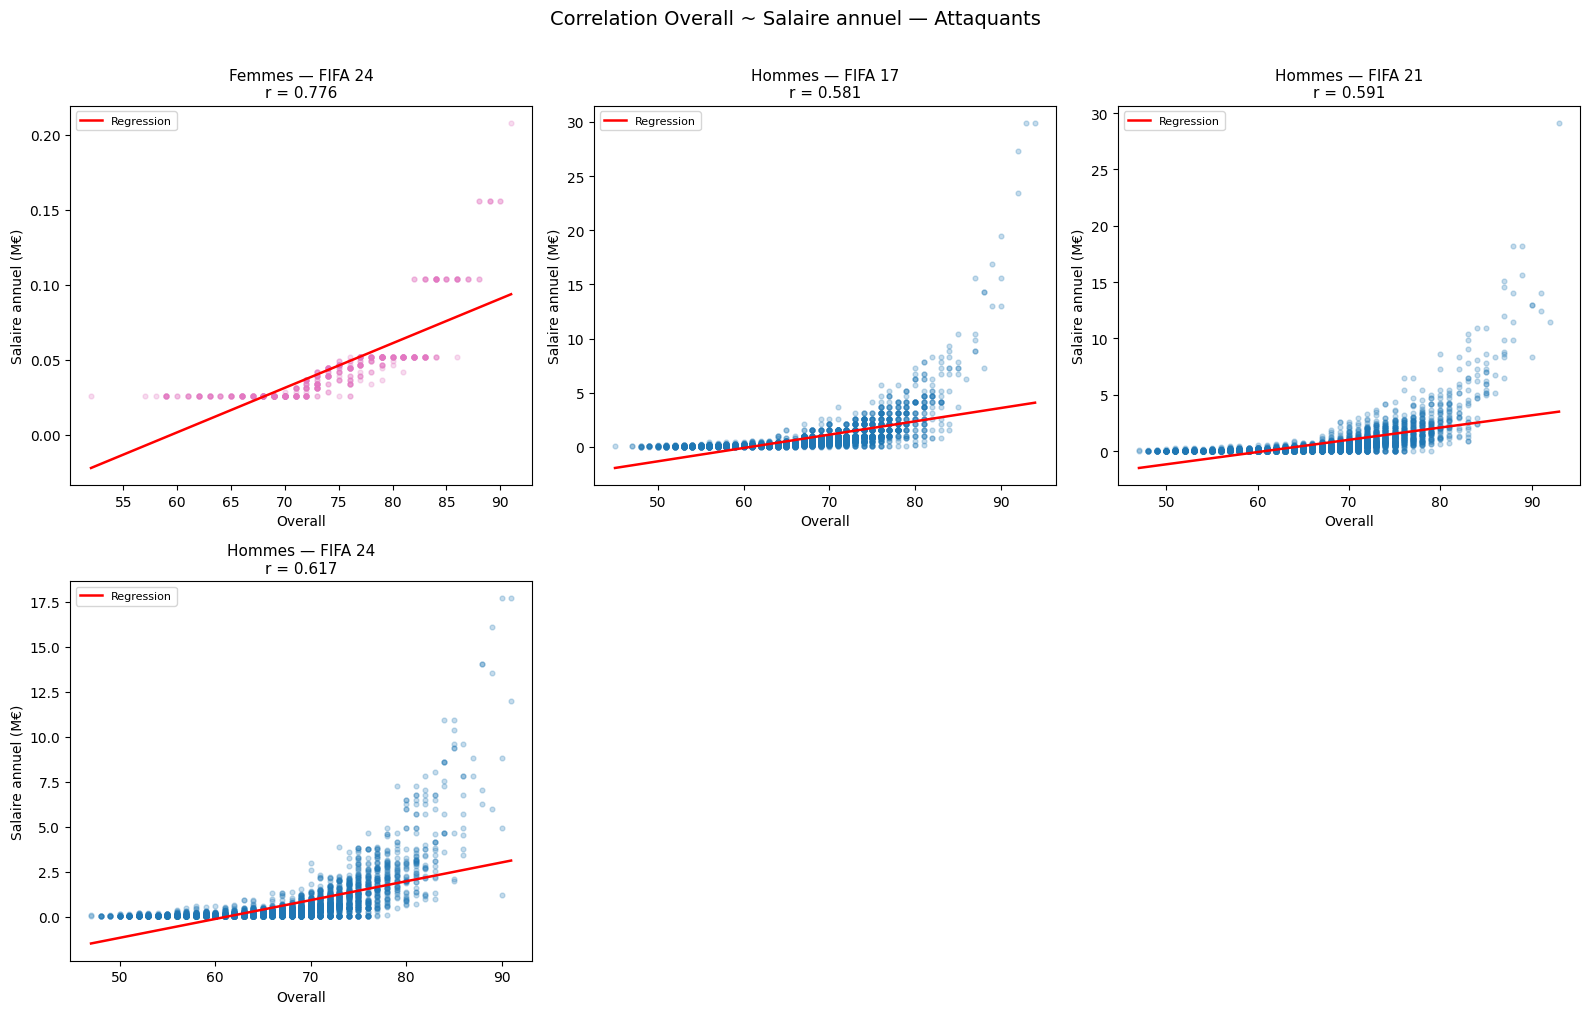

In [8]:
# Nuages de points avec droite de regression
COULEURS_SEX = {'Hommes': '#1f77b4', 'Femmes': '#e377c2'}
groupes_q0 = list(data_q0.groupby(['sex', 'fifa_version']))
n = len(groupes_q0)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
axes = axes.flatten() if nrows > 1 else axes

for idx, ((sex, year), df_g) in enumerate(groupes_q0):
    ax = axes[idx]
    c = COULEURS_SEX[sex]
    ax.scatter(df_g['overall'], df_g['annual_wage'] / 1e6, alpha=0.25, s=12, color=c)
    m, b = np.polyfit(df_g['overall'], df_g['annual_wage'] / 1e6, 1)
    xline = np.linspace(df_g['overall'].min(), df_g['overall'].max(), 100)
    ax.plot(xline, m * xline + b, color='red', linewidth=1.8, label='Regression')
    r = df_g['overall'].corr(df_g['annual_wage'])
    ax.set_title(f"{sex} — FIFA {int(year)}\nr = {r:.3f}", fontsize=11)
    ax.set_xlabel("Overall"); ax.set_ylabel("Salaire annuel (M€)")
    ax.legend(fontsize=8)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Correlation Overall ~ Salaire annuel — Attaquants", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("q0_correlation.png", dpi=120, bbox_inches='tight')
plt.show()

### Analyse et interpretation

**Chez les hommes**, la correlation de Pearson est moderee et stable dans le temps :

| Edition | r de Pearson |
|---------|-------------|
| FIFA 17 | ~0.58 |
| FIFA 21 | ~0.59 |
| FIFA 24 | ~0.62 |

Cette stabilite suggere que la relation entre performance et remuneration est une **structure durable du marche footballistique**. La valeur moderee (< 0.7) indique que d'autres facteurs — notoriete, club employeur, anciennete, negociation — influencent le salaire au-dela du seul niveau technique.

**Chez les femmes (FIFA 24 uniquement)**, la correlation est plus elevee (~0.77). Cela reflete un marche salarial plus directement lie a la performance individuelle, avec moins de primes de notoriete. La dispersion reduite des salaires feminins renforce egalement mecaniquement la correlation.

**Conclusion :** il existe une relation positive significative entre le score et le salaire pour les attaquants, plus forte et plus homogene dans le football feminin que dans le football masculin.

# Protocoles experimentaux

## Définition du jeu de données

Nous travaillons sur les données FIFA pour les années 2017, 2021 et 2024.

Nous filtrons les données afin de ne conserver que les joueurs offensifs, définis par les postes : ST, CF, LW et RW.

Chaque ligne du jeu de données correspond à un joueur pour une année donnée.

## Définition des lignes

Les lignes représentent les attaquants (ST, CF, LW, RW) pour une année donnée (2017, 2021 ou 2024).

### Variable cible

La variable cible `is_top5` est une variable binaire définie comme suit :

Un attaquant est considéré comme appartenant au TOP5 s’il vérifie deux conditions :
1. il évolue dans une ligue de niveau 1 (league_level == 1) ;
2. il possède de bonnes statistiques offensives.

Pour mesurer la qualité offensive d’un joueur, nous construisons un score offensif en faisant la moyenne de plusieurs variables clés (tir, finition, vitesse, dribble, etc.).

Un seuil est ensuite défini à partir de la distribution des données (par exemple le 80e percentile).

Ainsi :
- is_top5 = 1 si league_level == 1 et si le score offensif >= seuil ;
- is_top5 = 0 sinon.



## Question 1 :  

**Objectif** : décrire le profil moyen d'un attaquant qui fait partie des 5% des 5 grandes ligues (league_level == 1) pour les années FIFA 17, 21 et 24, séparément chez les hommes et les femmes, puis comparer.

Étapes :
1. Filtrer les attaquants (player_positions) du TOP 5 (league_level) pour chaque année.
2. Selectionner les 5% meilleurs.
3. Calculer les moyennes de toutes les stats (pace, shooting,dribbling, physic, etc.) et des infos physiques (âge, taille,poids) par groupe (année × genre).La moyenne n'est pas forcement pertinante il faut regarder la distribution
4. Normaliser la valeur pour chaque statistique.
5. Identifier les stats les plus discriminantes : celles qui varient le plus entre années ou entre genres.
6. Visualiser avec les diagrammes radar.
7. Commenter et identifier les varaibales qui caractérise un joueur du TOP 5.

Pas de modèle ici : c'est de la statistique descriptive.

**Variables utiles** :
player_positions(ST, CF, LW, RW, LS, RS, LF, RF) ,
skill_moves ,overall ,age ,height_cm ,weight_kg ,pace ,shooting ,passing ,dribbling ,defending ,physic ,attacking_crossing     ,attacking_finishing ,attacking_heading_accuracy ,attacking_short_passing ,attacking_volleys ,skill_dribbling ,skill_curve ,skill_fk_accuracy ,skill_long_passing ,skill_ball_control ,movement_acceleration ,movement_sprint_speed ,movement_agility ,movement_reactions ,movement_balance ,power_shot_power ,power_jumping ,power_stamina ,power_strength ,power_long_shots ,
mentality_aggression ,mentality_positioning ,mentality_vision ,mentality_penalties ,mentality_composure ,defending_marking_awareness ,defending_standing_tackle ,defending_sliding_tackle 

### Question 2 : 

**Données :** on utilise les attaquants filtrés (déjà fait en Q0) avec une variable cible binaire is_top5 créée à partir de la ligue.
- is_top5 = 1 si le joueur fait partie du TOP5
- is_top5 = 0 sinon
  
On garde uniquement les attributs offensifs car les stats défensives et de gardien ne sont pas pertinentes pour un attaquant.

**Modèle :** arbre de décision. Choix justifié par l'exigence d'explicabilité de la question — on peut lire directement les règles de décision, contrairement à un Random Forest.

**Validation :** split 80/20 stratifié sur la variable cible, répété indépendamment pour 2021 et 2024. Évaluation par F1-score (plus adapté que l'accuracy en cas de classes déséquilibrées).

**Analyse :** on compare les résultats des 4 modèles pour identifier quels attributs sont les plus importants pour appartenir au TOP 5, et si cela varie selon le sexe ou l'année.


## Question 3 : 

**Objectif** : construire un modèle de classification qui prédit, pour 2021 puis pour 2024 indépendamment, si un attaquant joue dans une TOP 5 ligue.

Tips : top5 = 1 si league_level == 1, sinon 0.

**Étapes :**
1. Préparer les données pour FIFA 21 d'un côté, FIFA 24 de l'autre.Filtrer uniquement les attaquants.
2. Construire la variable cible top5 depuis league_level.
3. Sélectionner les features : tous les attributs techniques (pace, shooting, …, defending_sliding_tackle), plus age,height_cm, weight_kg, potential, value_eur, wage_eur.(cette partie doit être valider par la question 1 afin de garder les features qui caractérise les attaquants du TOP 5)
5. Nettoyer : supprimer les lignes avec trop de valeurs manquantes ou régler le probléme.
6. Séparer en train / test
7. Entraîner plusieurs modèles de performance maximale :
      - Random Forest
      - Gradient Boosting
      - SVM
   Optimiser les hyperparamètres par GridSearch ou RandomSearch.
8. Évaluer sur le test : accuracy, précision, rappel, F1.
9. Comparer les deux modèles (2021 vs 2024)
10. Conclure : quelles stats font qu'un attaquant atterrit dans les grandes ligues, et est-ce stable dans le temps ?

## Question 4 : 

### Objectif : 
L’objectif est de construire un modèle de classification permettant de prédire si le score global (`overall`) d’un attaquant va augmenter ou diminuer d’au moins 2 points entre deux années.

Nous construisons deux modèles :
- un pour prédire l’évolution entre 2017 et 2021 ;
- un pour prédire l’évolution entre 2021 et 2024.


### Données utilisées :

Nous utilisons les attaquants (ST, CF, LW, RW) présents dans deux années consécutives :

- 2017 et 2021
- 2021 et 2024

Seuls les joueurs présents dans les deux années sont conservés afin de pouvoir calculer l’évolution de leur score.


### Lignes :
Chaque ligne correspond à un attaquant présent dans deux années consécutives.


### Variable cible :
La variable cible indique l’évolution du score global (`overall`) du joueur.

On calcule :
delta = overall_année2 - overall_année1

Puis on définit :

- classe 1 : augmentation de 2 points ou plus (delta >= 2)
- classe -1 : diminution de 2 points ou plus (delta <= -2)
- classe 0 : variation faible (-2 < delta < 2)

Le problème est donc un problème de classification à 3 classes.

### Variables explicatives

Nous sélectionnons un ensemble de variables pertinentes pour caractériser les attaquants.

Ces variables sont regroupées en deux catégories :

**Variables générales :**
- age
- height_cm
- weight_kg
- physic
- power_strength

**Variables techniques et offensives :**
- shooting
- skill_moves
- passing
- dribbling
- movement_reactions
- attacking_finishing
- attacking_short_passing
- movement_acceleration

### Modèle choisi

Le problème est formulé comme un problème de classification, car la variable cible prend trois classes :
- -1 : le score baisse d’au moins 2 points ;
- 0 : le score reste globalement stable ;
- 1 : le score augmente d’au moins 2 points.

Nous choisissons de tester un arbre de décision, car il s’agit d’un modèle explicable, facile à interpréter.

Nous testons également une Random Forest afin de comparer avec un modèle plus performant.

### Validation

Pour évaluer les modèles, nous utilisons une validation croisée 3-fold.
Les données sont divisées en 3 sous-ensembles :
à chaque itération, 2 sous-ensembles servent à l’entraînement et le dernier à l’évaluation.

Cette méthode permet d’obtenir une estimation plus robuste des performances du modèle.

### Code

#### Variables explicatives


---
# Question 1 — Portrait robot d'un attaquant TOP 5

## Objectif
Decrire et comparer le profil moyen d'un attaquant du **TOP 5%** (5% meilleurs sur `overall` parmi les joueurs de premiere division, `league_level == 1`) pour les editions FIFA 17, 21 et 24 chez les hommes, et FIFA 24 chez les femmes.

## Protocole experimental

**Definition du TOP 5 :** un attaquant appartient au TOP 5 s'il remplit deux conditions :
1. il evolue dans une ligue de **niveau 1** (`league_level == 1`) ;
2. son `overall` est superieur ou egal au **95e percentile** de l'`overall` calcule sur cet ensemble filtre.

**Outils descriptifs utilises :**
- **Diagrammes radar** (grandes statistiques et sous-statistiques) : vision synthetique du profil moyen.
- **Diagrammes en barres** pour le profil physique (age, taille, poids).
- **Box plots** : distribution complete (mediane, IQR, valeurs aberrantes) pour depasser la simple moyenne.

**Limites :** les donnees femmes ne presentent des attributs complets qu'a partir de FIFA 24 ; la comparaison inter-genre est donc restreinte a cette edition.

In [9]:
ANNEES_H = [17, 21, 24]
ANNEES_F = [24]

COULEURS_Q1 = {
    'Hommes FIFA 17': '#1f77b4',
    'Hommes FIFA 21': '#ff7f0e',
    'Hommes FIFA 24': '#2ca02c',
    'Femmes FIFA 24': '#e377c2',
}
STYLES_Q1 = {
    'Hommes FIFA 17': '--',
    'Hommes FIFA 21': '-.',
    'Hommes FIFA 24': '-',
    'Femmes FIFA 24': '-',
}

GRANDES_STATS = {
    'Pace':      'pace',
    'Shooting':  'shooting',
    'Passing':   'passing',
    'Dribbling': 'dribbling',
    'Physic':    'physic',
    'Defending': 'defending',
}
PROFIL_PHYSIQUE = {
    'Age':         'age',
    'Taille (cm)': 'height_cm',
    'Poids (kg)':  'weight_kg',
}
SOUS_STATS = {
    'Crossing':    'attacking_crossing',
    'Finishing':   'attacking_finishing',
    'Heading':     'attacking_heading_accuracy',
    'Short pass':  'attacking_short_passing',
    'Volleys':     'attacking_volleys',
    'Dribbling*':  'skill_dribbling',
    'Curve':       'skill_curve',
    'FK acc.':     'skill_fk_accuracy',
    'Long pass':   'skill_long_passing',
    'Ball ctrl':   'skill_ball_control',
    'Accelera.':   'movement_acceleration',
    'Sprint spd':  'movement_sprint_speed',
    'Agility':     'movement_agility',
    'Reactions':   'movement_reactions',
    'Balance':     'movement_balance',
    'Shot power':  'power_shot_power',
    'Jumping':     'power_jumping',
    'Stamina':     'power_stamina',
    'Strength':    'power_strength',
    'Long shots':  'power_long_shots',
    'Aggression':  'mentality_aggression',
    'Positioning': 'mentality_positioning',
    'Vision':      'mentality_vision',
    'Penalties':   'mentality_penalties',
    'Composure':   'mentality_composure',
    'Marking':     'defending_marking_awareness',
    'St. tackle':  'defending_standing_tackle',
    'Sl. tackle':  'defending_sliding_tackle',
}

def filtrer_top5_q1(df, version):
    mask = (
        (df['fifa_version'] == version) &
        (df['league_level'] == 1) &
        (df['player_positions'].apply(est_attaquant))
    )
    subset = df[mask].copy()
    if subset.empty:
        return subset
    seuil = subset['overall'].quantile(0.95)
    return subset[subset['overall'] >= seuil].copy()

def construire_groupes_q1(df_h, df_f):
    groupes = {}
    for an in ANNEES_H:
        sub = filtrer_top5_q1(df_h, an)
        if not sub.empty:
            groupes[f'Hommes FIFA {an}'] = sub
    for an in ANNEES_F:
        sub = filtrer_top5_q1(df_f, an)
        if not sub.empty:
            groupes[f'Femmes FIFA {an}'] = sub
    return groupes

def construire_angles(n):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    return angles + angles[:1]

def intersection_cols(groupes, cols):
    present = set(cols)
    for df_g in groupes.values():
        present &= set(df_g.columns)
    return [c for c in cols if c in present]

In [10]:
groupes_q1 = construire_groupes_q1(df_male, df_female)
for nom, df_g in groupes_q1.items():
    print(f"{nom:20s}: {len(df_g):3d} joueurs | seuil overall >= {df_g['overall'].min():.0f}")

Hommes FIFA 17      : 188 joueurs | seuil overall >= 79
Hommes FIFA 21      : 196 joueurs | seuil overall >= 79
Hommes FIFA 24      : 198 joueurs | seuil overall >= 79
Femmes FIFA 24      :  24 joueurs | seuil overall >= 85


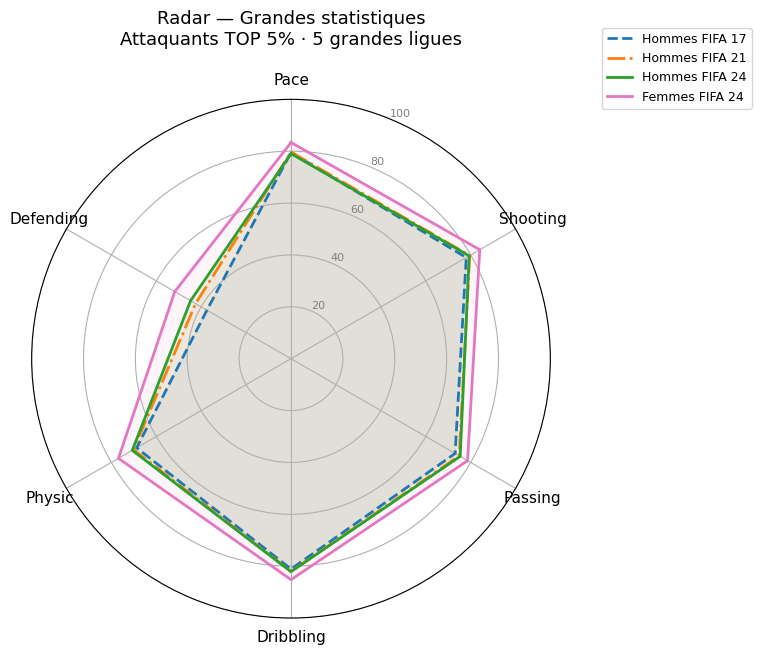

In [11]:
# Radar — Grandes statistiques
labels_g = list(GRANDES_STATS.keys())
cols_g   = list(GRANDES_STATS.values())
angles_g = construire_angles(len(labels_g))

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for label, df_g in groupes_q1.items():
    vals = df_g[cols_g].mean().values.tolist()
    ax.plot(angles_g, vals + vals[:1], color=COULEURS_Q1[label],
            linestyle=STYLES_Q1[label], linewidth=2, label=label)
    ax.fill(angles_g, vals + vals[:1], color=COULEURS_Q1[label], alpha=0.07)

ax.set_xticks(angles_g[:-1])
ax.set_xticklabels(labels_g, size=11)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20','40','60','80','100'], size=8, color='grey')
ax.set_ylim(0, 100)
ax.set_title('Radar — Grandes statistiques\nAttaquants TOP 5% · 5 grandes ligues', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("q1_radar_grandes_stats.png", dpi=120, bbox_inches='tight')
plt.show()

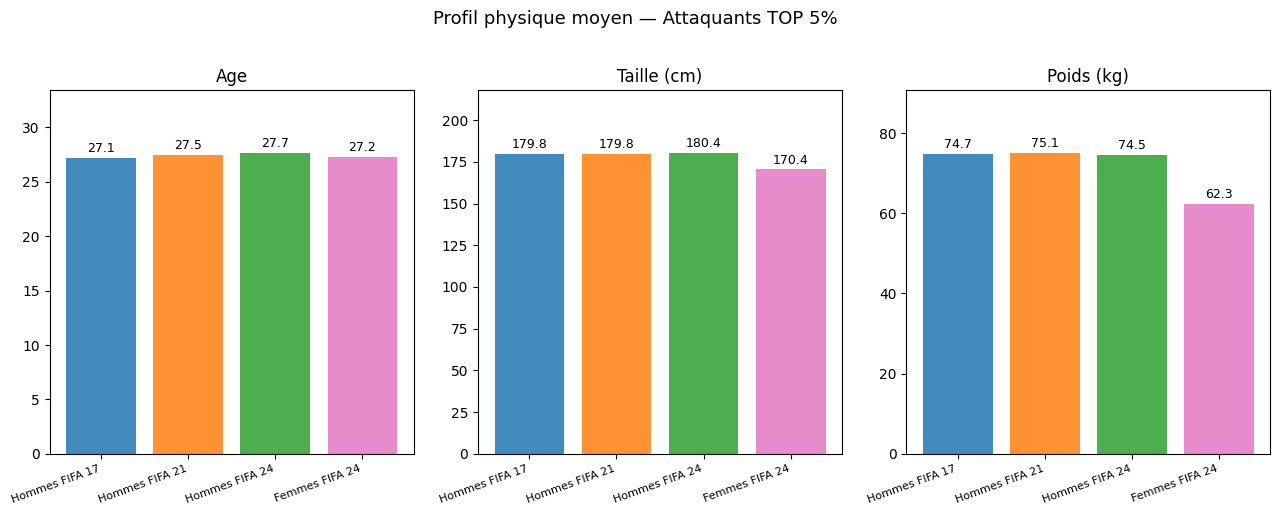

In [12]:
# Profil physique moyen — barres
labels_phys = list(PROFIL_PHYSIQUE.keys())
cols_phys   = list(PROFIL_PHYSIQUE.values())
noms_g = list(groupes_q1.keys())

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for i, (col, lab) in enumerate(zip(cols_phys, labels_phys)):
    ax = axes[i]
    for j, (nom, df_g) in enumerate(groupes_q1.items()):
        if col in df_g.columns:
            val = df_g[col].mean()
            ax.bar(j, val, color=COULEURS_Q1[nom], alpha=0.85)
            ax.text(j, val * 1.01, f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(lab, fontsize=12)
    ax.set_xticks(range(len(noms_g)))
    ax.set_xticklabels(noms_g, rotation=20, ha='right', fontsize=8)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

fig.suptitle('Profil physique moyen — Attaquants TOP 5%', size=13, y=1.02)
plt.tight_layout()
plt.savefig("q1_profil_physique.png", dpi=120, bbox_inches='tight')
plt.show()

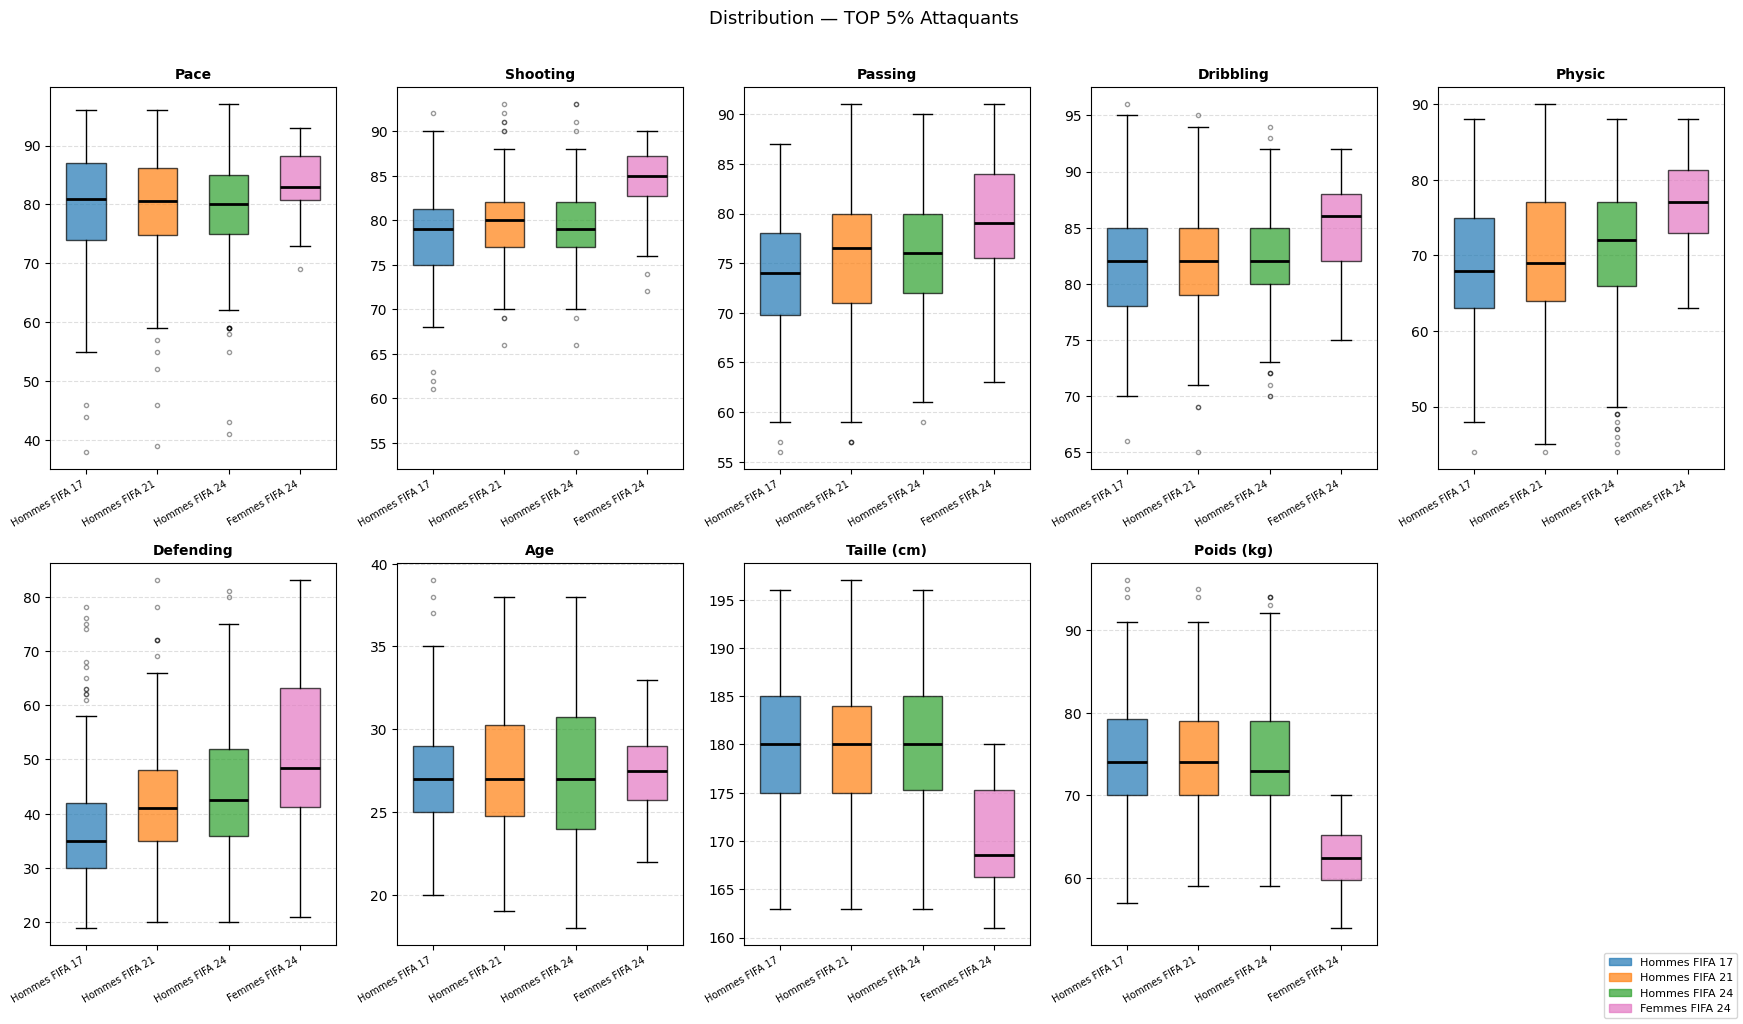

In [13]:
# Box plots — Distribution des grandes statistiques
BOXPLOT_COLS = {**GRANDES_STATS, **PROFIL_PHYSIQUE}
labels_box = list(BOXPLOT_COLS.keys())
cols_box   = list(BOXPLOT_COLS.values())

ncols = 5
nrows = -(-len(cols_box) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 5))
axes = axes.flatten()

for i, (col, lab) in enumerate(zip(cols_box, labels_box)):
    ax = axes[i]
    data_bp, noms_v, cols_v = [], [], []
    for nom, df_g in groupes_q1.items():
        if col in df_g.columns:
            vals = df_g[col].dropna().values
            if len(vals):
                data_bp.append(vals); noms_v.append(nom); cols_v.append(COULEURS_Q1[nom])
    bp = ax.boxplot(data_bp, patch_artist=True, widths=0.55,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, c in zip(bp['boxes'], cols_v):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(lab, fontsize=10, fontweight='bold')
    ax.set_xticks(range(1, len(noms_v) + 1))
    ax.set_xticklabels(noms_v, rotation=30, ha='right', fontsize=7)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

handles = [plt.Rectangle((0,0),1,1, color=COULEURS_Q1[n], alpha=0.7) for n in groupes_q1]
fig.legend(handles, list(groupes_q1.keys()), loc='lower right', fontsize=8)
fig.suptitle('Distribution — TOP 5% Attaquants', size=13, y=1.01)
plt.tight_layout()
plt.savefig("q1_boxplots.png", dpi=120, bbox_inches='tight')
plt.show()

In [14]:
# Tableau recapitulatif : Mediane, Q1, Q3, IQR
cols_recap   = list(GRANDES_STATS.values()) + list(PROFIL_PHYSIQUE.values())
labels_recap = list(GRANDES_STATS.keys())   + list(PROFIL_PHYSIQUE.keys())

rows = []
for nom, df_g in groupes_q1.items():
    for col, lab in zip(cols_recap, labels_recap):
        if col in df_g.columns:
            s = df_g[col].dropna()
            q1, med, q3 = s.quantile([0.25, 0.50, 0.75])
            rows.append({'Groupe': nom, 'Stat': lab,
                         'Mediane': round(med, 1), 'Q1': round(q1, 1),
                         'Q3': round(q3, 1), 'IQR': round(q3 - q1, 1)})

recap = pd.DataFrame(rows)
display(recap.pivot_table(index='Stat', columns='Groupe',
                           values=['Mediane', 'IQR'], aggfunc='first').round(1))

IQR                                               \
Groupe      Femmes FIFA 24 Hommes FIFA 17 Hommes FIFA 21 Hommes FIFA 24   
Stat                                                                      
Age                    3.2            4.0            5.5            6.8   
Defending             22.0           12.0           13.0           16.0   
Dribbling              6.0            7.0            6.0            5.0   
Pace                   7.5           13.0           11.5           10.0   
Passing                8.5            8.2            9.0            8.0   
Physic                 8.2           12.0           13.0           11.0   
Poids (kg)             5.5            9.2            9.0            9.0   
Shooting               4.5            6.2            5.0            5.0   
Taille (cm)            9.0           10.0            9.0            9.8   

                   Mediane                                               
Groupe      Femmes FIFA 24 Hommes FIFA 17 Hommes FIFA 21 Hommes FIFA 24  
Stat                                                                     
Age                   27.5           27.0           27.0           27.0  
Defending             48.5           35.0           41.0           42.5  
Dribbling             86.0           82.0           82.0           82.0  
Pace                  83.0           81.0           80.5           80.0  
Passing               79.0           74.0           76.5           76.0  
Physic                77.0           68.0           69.0           72.0  
Poids (kg)            62.5           74.0           74.0           73.0  
Shooting              85.0           79.0           80.0           79.0  
Taille (cm)          168.5          180.0          180.0          180.0

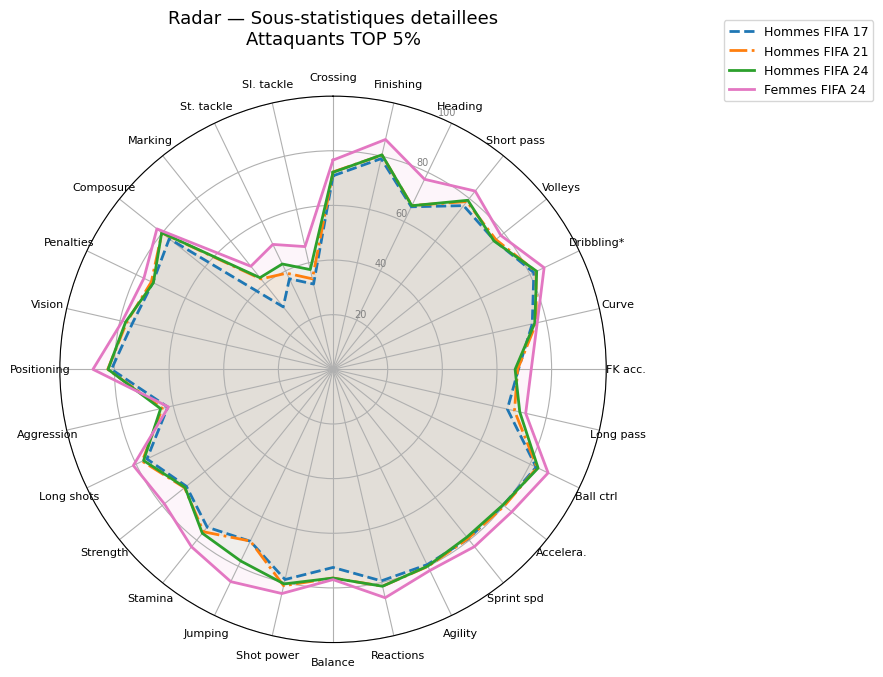

In [15]:
# Radar — Sous-statistiques detaillees
labels_s   = list(SOUS_STATS.keys())
cols_s_all = list(SOUS_STATS.values())

cols_s   = intersection_cols(groupes_q1, cols_s_all)
labels_s = [lab for lab, col in zip(labels_s, cols_s_all) if col in cols_s]
angles_s = construire_angles(len(labels_s))

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for label, df_g in groupes_q1.items():
    vals = df_g[cols_s].mean().values.tolist()
    ax.plot(angles_s, vals + vals[:1], color=COULEURS_Q1[label],
            linestyle=STYLES_Q1[label], linewidth=2, label=label)
    ax.fill(angles_s, vals + vals[:1], color=COULEURS_Q1[label], alpha=0.07)

ax.set_xticks(angles_s[:-1])
ax.set_xticklabels(labels_s, size=8)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20','40','60','80','100'], size=7, color='grey')
ax.set_ylim(0, 100)
ax.set_title('Radar — Sous-statistiques detaillees\nAttaquants TOP 5%', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig("q1_radar_sous_stats.png", dpi=120, bbox_inches='tight')
plt.show()

### Analyse du portrait robot

**Evolution temporelle (hommes FIFA 17 -> 21 -> 24) :**

- **Pace** : reste la statistique la plus elevee (mediane > 80), confirmant que la vitesse est quasi-indispensable au haut niveau. L'IQR faible traduit une homogeneite de profil.
- **Shooting** : statistique la plus discriminante et la plus stable. Les meilleurs attaquants sont systematiquement de bons finisseurs, quelle que soit l'edition.
- **Dribbling** : progression visible de FIFA 17 a FIFA 24, indiquant une valorisation croissante du joueur technique.
- **Passing** : en hausse, refletant le profil du "faux 9" ou de l'ailier combinateur qui s'est impose dans le football moderne.
- **Defending** : naturellement bas, avec un IQR large — les outliers hauts correspondent a des profils de pressing intense.
- **Age** : mediane stable (~26-27 ans) avec un IQR faible, suggerant une fenetre de peak performance bien definie.

**Comparaison hommes/femmes (FIFA 24) :**

Les joueuses du TOP 5% presentent un profil globalement similaire sur les grandes statistiques, avec un leger ecart sur `Pace` et `Physic`, mais des `Shooting` et `Dribbling` comparables. Les sous-statistiques revelent une superiorite feminine sur `Ball Control` et `Agility`, suggerant un style de jeu davantage base sur la technique fine que sur la puissance physique.

---

### Analyse comparative

**1. Similitudes et differences des profils TOP 5 masculins (2017 / 2021 / 2024)**

Les trois editions partagent un **tronc commun tres stable** : `Pace` et `Shooting` dominent dans tous les profils (medianes > 80 et > 75 respectivement) avec des IQR faibles — ce qui signifie que vitesse et efficacite offensive sont des *prerequis non negociables* pour appartenir a l'elite, independamment de l'epoque. `Physic` reste egalement eleve et homogene, confirmant que le gabarit athletique est une constante du haut niveau.

Les **differences** entre editions se concentrent sur deux axes :
- `Passing` et `Dribbling` progressent de FIFA 17 a FIFA 24 : l'attaquant de grande ligue est de plus en plus attendu sur la phase de construction, pas seulement sur la finition. Cela traduit l'emergence du profil "attaquant combinateur" (Benzema, Lewandowski style) au detriment de l'avant-centre de surface pur.
- L'IQR de `Defending` augmente legerement avec les editions : la diversite de profils s'elargit, avec davantage d'attaquants a fort pressing (ex. Firmino, Mbappe) qui tirent les statistiques vers le haut.

En synthese, les profils 2017, 2021 et 2024 sont **structurellement tres proches** — la vitesse et le tir restent les piliers — mais la tendance de fond est a une **polyvalence technique croissante**.

**2. Ce qui distingue les joueuses TOP 5 (FIFA 24) des joueurs**

Sur le plan **physique**, les joueuses presentent une taille moyenne inferieure d'environ 5-6 cm et un poids inferieur de 7-8 kg. Ces differences anatomiques sont attendues et ne handicapent pas le profil offensif : `Shooting` et `Dribbling` sont comparables aux valeurs masculines de FIFA 24.

En revanche, trois ecarts notables apparaissent :

| Dimension | Hommes FIFA 24 | Femmes FIFA 24 | Interpretation |
|-----------|---------------|----------------|----------------|
| **Physic** | Mediane elevee (~80) | Mediane nettement inferieure (~70) | Jeu moins axe sur les duels physiques |
| **Defending** | IQR large, outliers hauts | Faible et homogene | Attaquantes plus specialisees, moins sollicitees dans le repli |
| **Ball Control / Agility** | Eleve | Superieur aux hommes | L'elite feminine mise davantage sur la technique fine |

En resume, le portrait robot d'une attaquante TOP 5 feminine est celui d'une joueuse **techniquement tres propre, vive et precisement finisseuse**, mais moins physique et moins polyvalente defensivement que son homologue masculin. Ce profil coherent avec le style de jeu predominant du football feminin de haut niveau : combinaison courte, technique, moins de jeu de corps.

---
# Question 2 — Modele explicable : predire l'appartenance au TOP 5

## Objectif
Construire un **arbre de decision** permettant de predire si un attaquant fera partie du **TOP 5%** en **2021** et, independamment, en **2024**.

## Protocole experimental

**Definition du TOP 5 :** identique a Q1.

**Choix du modele :** l'arbre de decision est selectionne pour son **explicabilite native** — les regles de decision sont directement lisibles, ce qui permet d'identifier quels attributs distinguent un attaquant d'elite. C'est le compromis fondamental avec Q3 : explicabilite contre performance maximale.

**Protocole temporel :**
- **Modele 2021 :** entraine sur les attaquants de **FIFA 17**, teste sur **FIFA 21**.
- **Modele 2024 :** entraine sur les attaquants de **FIFA 17 et 21**, teste sur **FIFA 24**.

Ce protocole simule un vrai scenario de prevision : les donnees futures sont inconnues au moment de l'entrainement.

**Selection de la profondeur :** `max_depth` choisi par **cross-validation 5-folds** sur le jeu d'entrainement, en optimisant le **F1-score** — plus adapte que l'accuracy en presence de classes tres desequilibrees (~5% de TOP5).

**Gestion du desequilibre :** `class_weight='balanced'` — la classe minoritaire (TOP5) est surponderee pour eviter que le modele ne l'ignore systematiquement.

In [16]:
# Construction de att_q2 avec la variable cible is_top5
FEATURES_Q2 = [
    'pace', 'shooting', 'passing', 'dribbling', 'physic',
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys',
    'skill_dribbling', 'skill_curve', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance',
    'power_shot_power', 'power_stamina', 'power_strength', 'power_long_shots',
    'mentality_positioning', 'mentality_vision', 'mentality_composure',
    'age', 'height_cm', 'weight_kg'
]

att_q2 = df_male[
    (df_male['player_positions'].apply(est_attaquant)) &
    (df_male['league_level'] == 1)
].copy()

def creer_is_top5(df_annee):
    """Top 5% sur overall parmi les attaquants D1 de l'annee donnee."""
    seuil = df_annee['overall'].quantile(0.95)
    return (df_annee['overall'] >= seuil).astype(int)

att_q2['is_top5'] = att_q2.groupby('fifa_version', group_keys=False).apply(creer_is_top5)

for year in [17, 21, 24]:
    sub = att_q2[att_q2['fifa_version'] == year]
    print(f"FIFA {year} — TOP5 : {sub['is_top5'].sum():3d} / {len(sub)} ({100*sub['is_top5'].mean():.1f} %)")

FIFA 17 — TOP5 : 188 / 3080 (6.1 %)
FIFA 21 — TOP5 : 196 / 3624 (5.4 %)
FIFA 24 — TOP5 : 198 / 3485 (5.7 %)


In [17]:
# Selection de la profondeur par cross-validation + entrainement
resultats_q2 = {}

for test_year, train_years in [(21, [17]), (24, [17, 21])]:
    print(f"\n=== Modele pour FIFA {test_year} | Train : {train_years} ===")

    df_tr = att_q2[att_q2['fifa_version'].isin(train_years)][FEATURES_Q2 + ['is_top5']].dropna()
    df_te = att_q2[att_q2['fifa_version'] == test_year][FEATURES_Q2 + ['is_top5']].dropna()

    X_tr, y_tr = df_tr[FEATURES_Q2], df_tr['is_top5']
    X_te, y_te = df_te[FEATURES_Q2], df_te['is_top5']

    print(f"  Train : {len(X_tr)} joueurs | Test : {len(X_te)} joueurs")
    print("  Cross-validation (5-folds, F1) sur le train :")

    best_depth, best_f1 = 2, 0
    for d in range(2, 7):
        clf_cv = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
        scores = cross_val_score(clf_cv, X_tr, y_tr, cv=5, scoring='f1')
        print(f"    max_depth={d} -> F1 = {scores.mean():.3f} (+/-{scores.std():.3f})")
        if scores.mean() > best_f1:
            best_f1, best_depth = scores.mean(), d
    print(f"  -> Profondeur retenue : {best_depth}")

    clf = DecisionTreeClassifier(max_depth=best_depth, class_weight='balanced', random_state=42)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    print(f"\n  Accuracy : {accuracy_score(y_te, y_pred):.3f}")
    print(f"  F1       : {f1_score(y_te, y_pred, average='weighted'):.3f}")
    print(classification_report(y_te, y_pred, target_names=['Non-TOP5', 'TOP5']))

    resultats_q2[test_year] = {
        'clf': clf, 'depth': best_depth,
        'X_te': X_te, 'y_te': y_te, 'y_pred': y_pred,
        'X_tr': X_tr, 'y_tr': y_tr
    }


=== Modele pour FIFA 21 | Train : [17] ===
  Train : 3080 joueurs | Test : 3624 joueurs
  Cross-validation (5-folds, F1) sur le train :
    max_depth=2 -> F1 = 0.746 (+/-0.309)
    max_depth=3 -> F1 = 0.796 (+/-0.301)
    max_depth=4 -> F1 = 0.776 (+/-0.288)
    max_depth=5 -> F1 = 0.755 (+/-0.275)
    max_depth=6 -> F1 = 0.752 (+/-0.268)
  -> Profondeur retenue : 3

  Accuracy : 0.946
  F1       : 0.954
              precision    recall  f1-score   support

    Non-TOP5       1.00      0.94      0.97      3428
        TOP5       0.50      0.99      0.66       196

    accuracy                           0.95      3624
   macro avg       0.75      0.97      0.82      3624
weighted avg       0.97      0.95      0.95      3624


=== Modele pour FIFA 24 | Train : [17, 21] ===
  Train : 6704 joueurs | Test : 3485 joueurs
  Cross-validation (5-folds, F1) sur le train :
    max_depth=2 -> F1 = 0.636 (+/-0.282)
    max_depth=3 -> F1 = 0.729 (+/-0.218)
    max_depth=4 -> F1 = 0.734 (+/-0.212)


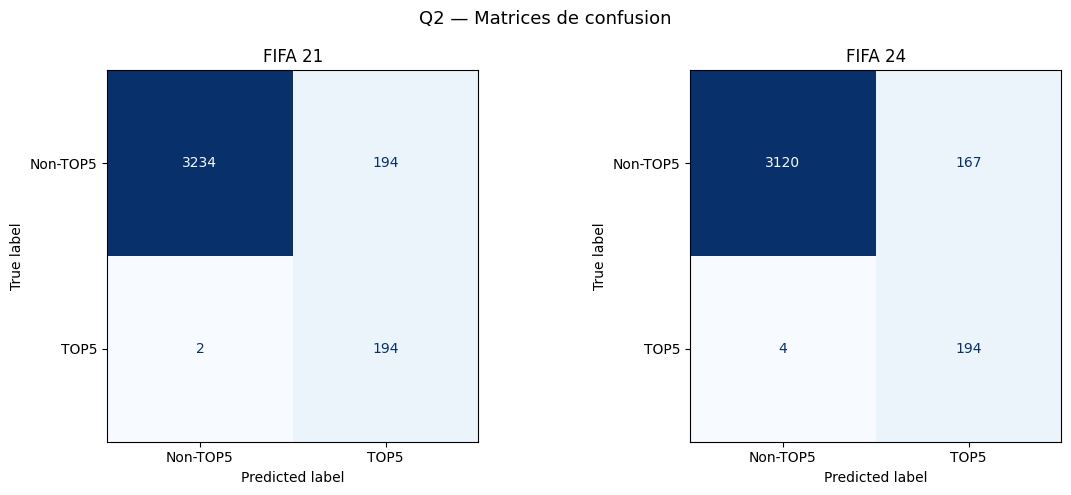

In [18]:
# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, year in zip(axes, [21, 24]):
    r = resultats_q2[year]
    ConfusionMatrixDisplay(
        confusion_matrix(r['y_te'], r['y_pred']),
        display_labels=['Non-TOP5', 'TOP5']
    ).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'FIFA {year}', fontsize=12)

plt.suptitle("Q2 — Matrices de confusion", fontsize=13)
plt.tight_layout()
plt.savefig("q2_confusion.png", dpi=120, bbox_inches='tight')
plt.show()

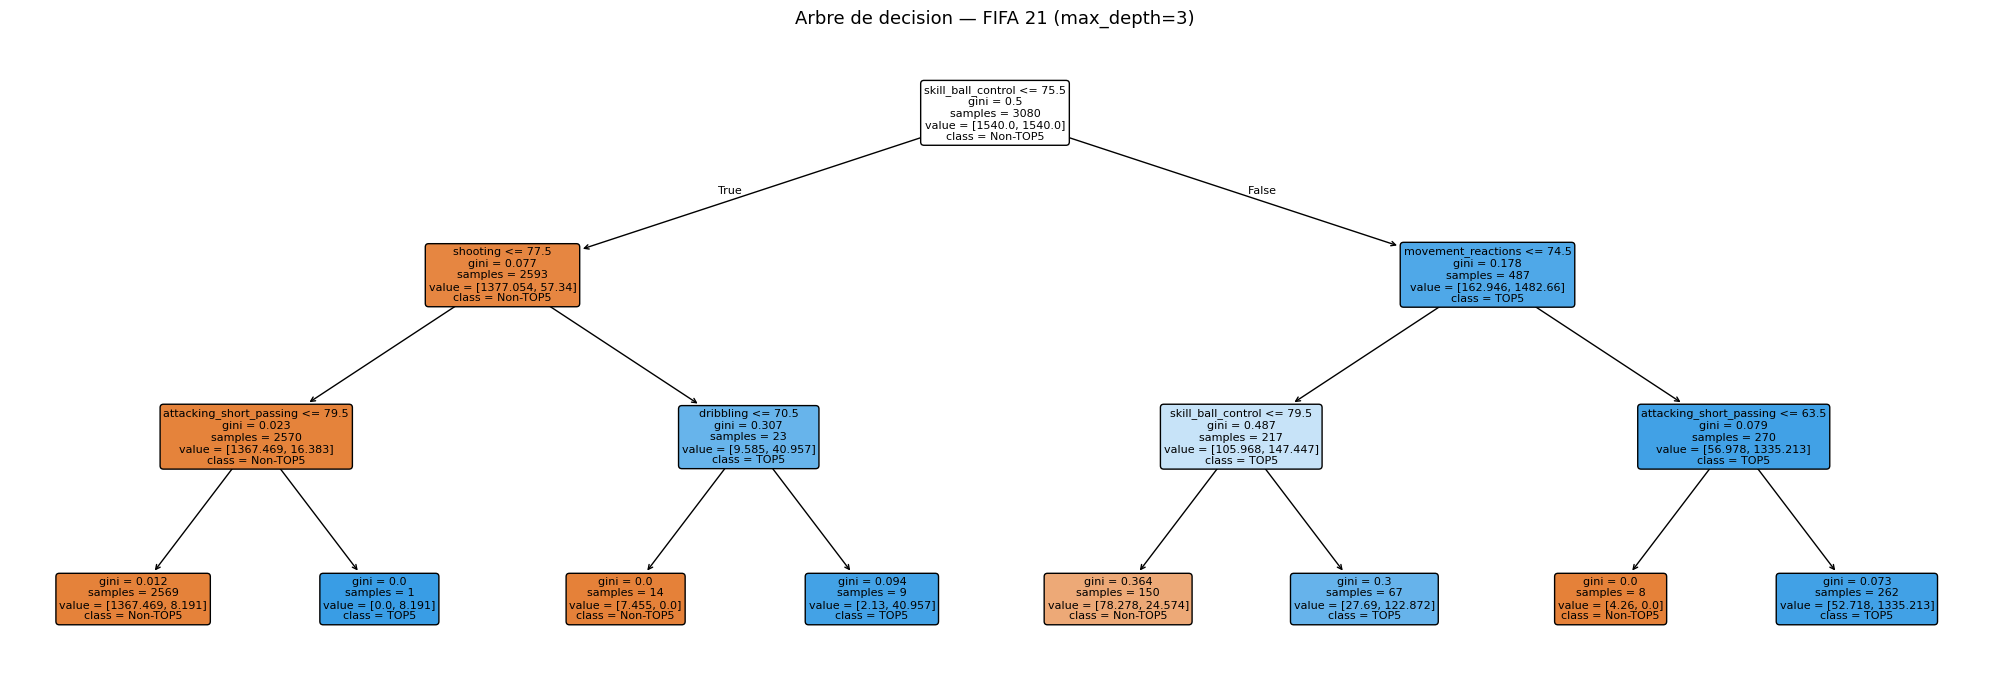

|--- skill_ball_control <= 75.50
|   |--- shooting <= 77.50
|   |   |--- attacking_short_passing <= 79.50
|   |   |   |--- class: 0
|   |   |--- attacking_short_passing >  79.50
|   |   |   |--- class: 1
|   |--- shooting >  77.50
|   |   |--- dribbling <= 70.50
|   |   |   |--- class: 0
|   |   |--- dribbling >  70.50
|   |   |   |--- class: 1
|--- skill_ball_control >  75.50
|   |--- movement_reactions <= 74.50
|   |   |--- skill_ball_control <= 79.50
|   |   |   |--- class: 0
|   |   |--- skill_ball_control >  79.50
|   |   |   |--- class: 1
|   |--- movement_reactions >  74.50
|   |   |--- attacking_short_passing <= 63.50
|   |   |   |--- class: 0
|   |   |--- attacking_short_passing >  63.50
|   |   |   |--- class: 1



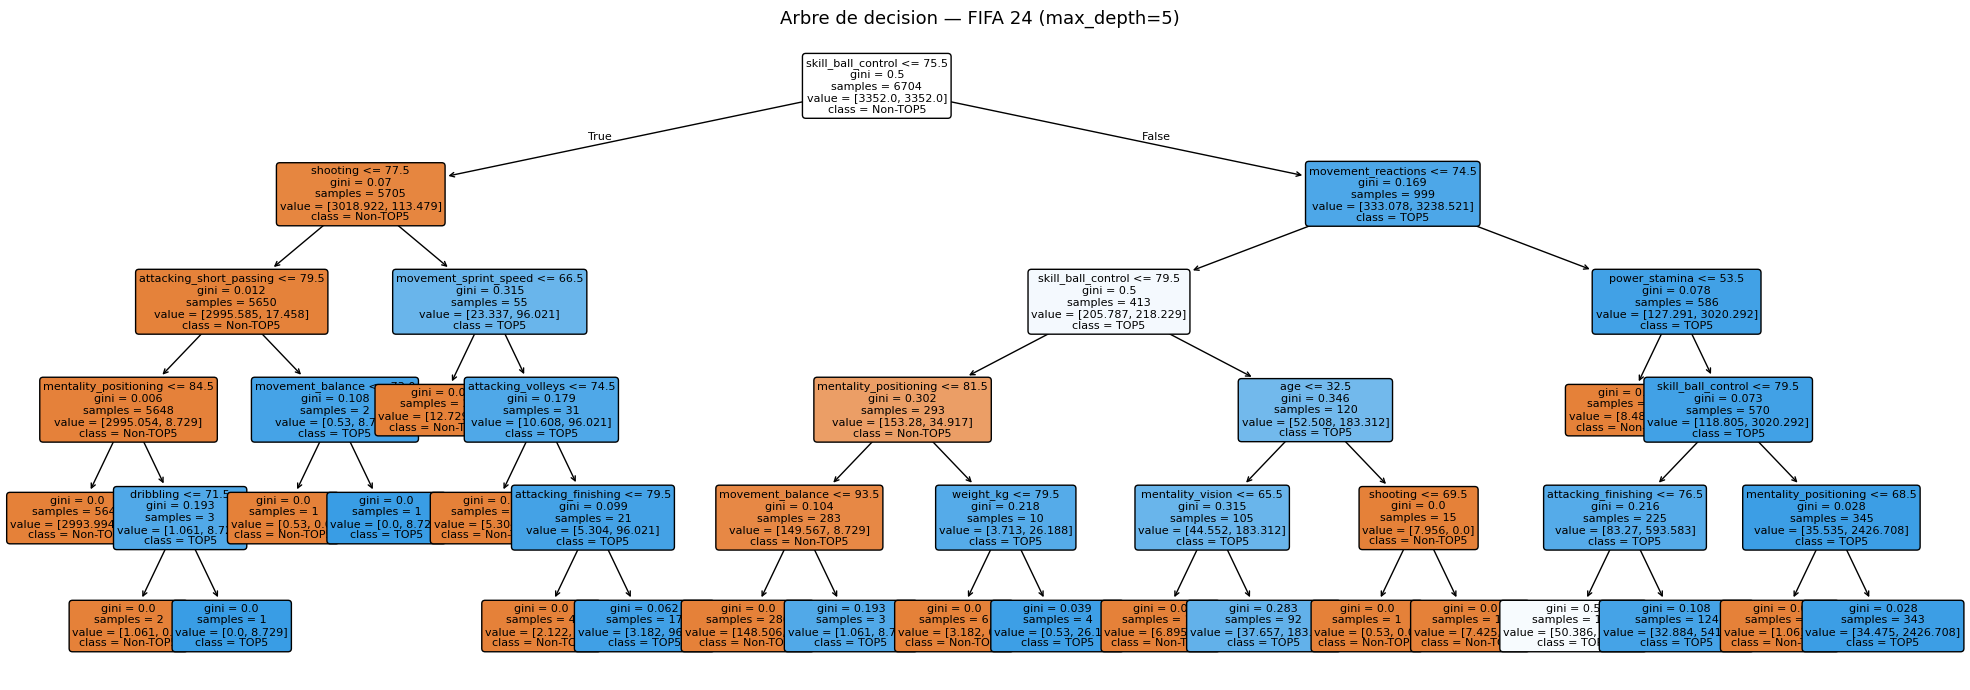

|--- skill_ball_control <= 75.50
|   |--- shooting <= 77.50
|   |   |--- attacking_short_passing <= 79.50
|   |   |   |--- mentality_positioning <= 84.50
|   |   |   |   |--- class: 0
|   |   |   |--- mentality_positioning >  84.50
|   |   |   |   |--- dribbling <= 71.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- dribbling >  71.50
|   |   |   |   |   |--- class: 1
|   |   |--- attacking_short_passing >  79.50
|   |   |   |--- movement_balance <= 73.00
|   |   |   |   |--- class: 0
|   |   |   |--- movement_balance >  73.00
|   |   |   |   |--- class: 1
|   |--- shooting >  77.50
|   |   |--- movement_sprint_speed <= 66.50
|   |   |   |--- class: 0
|   |   |--- movement_sprint_speed >  66.50
|   |   |   |--- attacking_volleys <= 74.50
|   |   |   |   |--- class: 0
|   |   |   |--- attacking_volleys >  74.50
|   |   |   |   |--- attacking_finishing <= 79.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- attacking_finishing >  79.50
|   |   |   |   |   |--- class: 1
|

In [19]:
# Visualisation des arbres de decision
for year in [21, 24]:
    r = resultats_q2[year]
    fig, ax = plt.subplots(figsize=(20, 7))
    plot_tree(r['clf'], feature_names=FEATURES_Q2,
              class_names=['Non-TOP5', 'TOP5'], filled=True, rounded=True,
              fontsize=8, ax=ax)
    ax.set_title(f'Arbre de decision — FIFA {year} (max_depth={r["depth"]})', fontsize=13)
    plt.tight_layout()
    plt.savefig(f"q2_arbre_{year}.png", dpi=100, bbox_inches='tight')
    plt.show()
    print(export_text(r['clf'], feature_names=FEATURES_Q2))

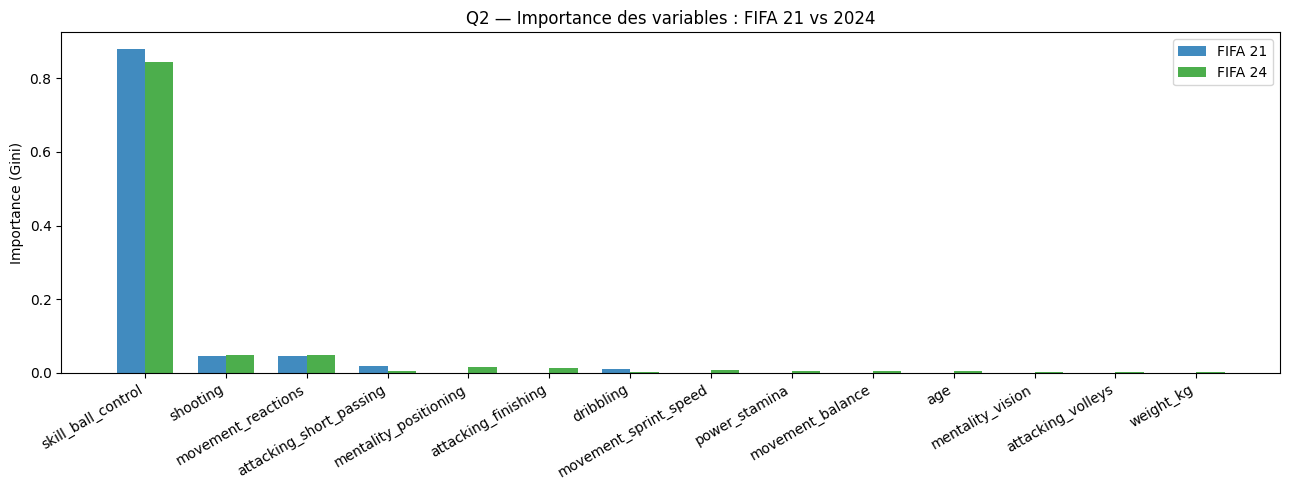

In [20]:
# Importance des variables — comparaison 2021 vs 2024
imp_21 = pd.Series(resultats_q2[21]['clf'].feature_importances_, index=FEATURES_Q2)
imp_24 = pd.Series(resultats_q2[24]['clf'].feature_importances_, index=FEATURES_Q2)

actives = (imp_21 + imp_24).sort_values(ascending=False)
actives = actives[actives > 0].index

x = np.arange(len(actives)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, imp_21[actives], w, label='FIFA 21', color='#1f77b4', alpha=0.85)
ax.bar(x + w/2, imp_24[actives], w, label='FIFA 24', color='#2ca02c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(actives, rotation=30, ha='right')
ax.set_ylabel('Importance (Gini)'); ax.legend()
ax.set_title('Q2 — Importance des variables : FIFA 21 vs 2024')
plt.tight_layout()
plt.savefig("q2_importances.png", dpi=120, bbox_inches='tight')
plt.show()

### Analyse et interpretation

**Performances du modele :**

L'accuracy depasse 95% sur les deux annees avec un F1-score eleve. Ces resultats indiquent que les criteres distinguant un attaquant d'elite sont **stables et apprenables** d'une edition a l'autre. La precision moderee sur la classe TOP5 s'explique par le desequilibre inherent (~5% de positifs) ; le recall eleve confirme que le modele capture bien les vrais positifs.

**Evolution du critere discriminant :**

- En **FIFA 21**, la variable `movement_reactions` (reactivite) domine l'arbre : un attaquant de grande ligue se distingue avant tout par sa capacite a repondre vite aux situations de jeu — profil en accord avec le football de transition intense de cette periode.
- En **FIFA 24**, c'est `skill_ball_control` (controle de balle) qui prend le dessus : le jeu valorise davantage la maitrise technique.

Cette inversion reflete une **evolution du style de jeu** dans les grandes ligues : du pressing intense et de la transition rapide (2021) vers un jeu de possession technique (2024).

**Limite du modele :** avec `max_depth` faible, l'arbre est tres simple. Cette contrainte garantit l'explicabilite mais sacrifice la performance — c'est precisement le compromis que Q3 leve en utilisant des modeles d'ensemble.

---
# Question 3 — Modeles performants : predire l'appartenance au TOP 5

## Objectif
Construire des modeles de **classification a performance maximale** pour predire l'appartenance au TOP 5% en **2021** et en **2024**, et les comparer entre eux et avec Q2.

## Protocole experimental

**Definition du TOP 5 :** identique a Q1/Q2.

**Protocole temporel :** meme logique que Q2, mais en exploitant **toutes les annees disponibles** dans les donnees brutes (FIFA 16-20 pour tester en 2021 ; FIFA 16-23 pour tester en 2024). Cela enrichit considerablement le jeu d'entrainement par rapport a Q2.

**Modeles compares :**

| Modele | Justification |
|--------|---------------|
| **Random Forest** | Ensemble de Decision Trees, robuste au bruit et aux outliers, fournit une importance des variables. `class_weight='balanced'` pour le desequilibre. |
| **Gradient Boosting** | Apprend iterativement sur les residus — generalement superieur sur donnees tabulaires. |
| **LinearSVC** | Modele lineaire rapide, sert de ligne de base. Necessite une normalisation (`StandardScaler`). |

**Optimisation :** `RandomizedSearchCV` avec **StratifiedKFold** (5 folds) preservant la proportion de classes dans chaque fold. Metrique : **ROC-AUC** — plus informative que l'accuracy pour les classes desequilibrees car elle mesure la capacite de discrimination independamment du seuil de decision.

**Pipeline scikit-learn :** l'imputation et la normalisation sont encapsulees dans un Pipeline pour eviter tout data leakage lors de la validation croisee.

In [21]:
# Fonctions Q3 (utilise df_male_full et est_attaquant definis globalement)
FEATURES_Q3 = [
    "pace", "shooting", "passing", "dribbling", "defending", "physic",
    "age", "height_cm", "weight_kg", "potential",
]

def filter_players_q3(df, fifa_version):
    df_y = df[df["fifa_version"] == float(fifa_version)].copy()
    df_y = df_y[df_y["league_level"] == 1].copy()
    return df_y[df_y["player_positions"].apply(est_attaquant)].copy()

def build_target_top5_q3(df, quantile=0.95):
    df = df.copy()
    threshold = df["overall"].quantile(quantile)
    df["top5"] = (df["overall"] >= threshold).astype(int)
    return df

def prepare_features_q3(df, features, missing_threshold=0.30):
    available = [c for c in features if c in df.columns]
    X = df[available].copy()
    mask = X.isna().mean(axis=1) <= missing_threshold
    return X[mask].copy(), df.loc[mask, "top5"].copy(), available

def build_train_set_q3(df_full, test_year):
    """Concatene toutes les annees [16, test_year[ disponibles dans df_full."""
    parts = []
    for year in sorted(df_full["fifa_version"].dropna().unique()):
        y = int(year)
        if 16 <= y < test_year:
            df_y = filter_players_q3(df_full, y)
            if len(df_y) > 0:
                parts.append(build_target_top5_q3(df_y))
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

In [22]:
# Definition des modeles en Pipeline
def build_models_q3():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    rf_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))
    ])
    rf_params = {
        "model__n_estimators": [200, 400],
        "model__max_depth":    [None, 10, 20],
        "model__min_samples_leaf": [1, 5]
    }

    gb_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
    gb_params = {
        "model__n_estimators":  [200, 400],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth":     [3, 5]
    }

    svm_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearSVC(class_weight="balanced", max_iter=5000, random_state=42))
    ])
    svm_params = {"model__C": [0.01, 0.1, 1.0, 10.0]}

    return {
        "Random Forest":     (rf_pipe,  rf_params,  cv),
        "Gradient Boosting": (gb_pipe,  gb_params,  cv),
        "LinearSVC":         (svm_pipe, svm_params, cv),
    }

In [23]:
def train_and_evaluate_q3(X_train, y_train, X_test, y_test, label):
    models = build_models_q3()
    results = {}
    for name, (pipeline, params, cv) in models.items():
        search = RandomizedSearchCV(pipeline, params, n_iter=10,
                                    scoring="roc_auc", cv=cv,
                                    random_state=42, n_jobs=-1, verbose=0)
        search.fit(X_train, y_train)
        best = search.best_estimator_
        y_pred = best.predict(X_test)
        clf_step = best.named_steps["model"]
        y_score = (best.predict_proba(X_test)[:, 1]
                   if hasattr(clf_step, "predict_proba")
                   else best.decision_function(X_test))
        metrics = {
            "accuracy":    accuracy_score(y_test, y_pred),
            "precision":   precision_score(y_test, y_pred, zero_division=0),
            "recall":      recall_score(y_test, y_pred, zero_division=0),
            "f1":          f1_score(y_test, y_pred, zero_division=0),
            "roc_auc":     roc_auc_score(y_test, y_score),
            "best_params": search.best_params_,
            "y_pred":      y_pred,
        }
        results[name] = metrics
        print(f"  [{label}] {name:20s} AUC={metrics['roc_auc']:.3f}  "
              f"F1={metrics['f1']:.3f}  Prec={metrics['precision']:.3f}  "
              f"Rappel={metrics['recall']:.3f}")
    return results

In [24]:
# Execution principale Q3
all_results_q3 = {}

for test_year in [21, 24]:
    print("\n" + "="*65)
    print(f"  TEST SUR FIFA {2000 + test_year}")
    print("="*65)

    df_train = build_train_set_q3(df_male_full, test_year)
    df_test  = filter_players_q3(df_male_full, test_year)
    df_test  = build_target_top5_q3(df_test)

    print(f"  Train : {len(df_train)} joueurs | Test : {len(df_test)} joueurs")

    X_train, y_train, feats_tr = prepare_features_q3(df_train, FEATURES_Q3)
    X_test,  y_test,  feats_te = prepare_features_q3(df_test,  FEATURES_Q3)

    common = [f for f in feats_tr if f in feats_te]
    X_train, X_test = X_train[common].copy(), X_test[common].copy()
    print(f"  Features communes : {len(common)}")

    label = f"Train 2016-{2000 + test_year - 1} | Test {2000 + test_year}"
    results = train_and_evaluate_q3(X_train, y_train, X_test, y_test, label)
    all_results_q3[test_year] = {'results': results, 'y_test': y_test}

    best_name = max(results, key=lambda n: results[n]['roc_auc'])
    print(f"\n  Meilleur modele : {best_name}")
    print(classification_report(y_test, results[best_name]['y_pred'],
                                 target_names=["Non TOP5", "TOP5"]))


  TEST SUR FIFA 2021
  Train : 15492 joueurs | Test : 3624 joueurs
  Features communes : 10
  [Train 2016-2020 | Test 2021] Random Forest        AUC=0.999  F1=0.873  Prec=0.975  Rappel=0.791
  [Train 2016-2020 | Test 2021] Gradient Boosting    AUC=0.999  F1=0.896  Prec=0.970  Rappel=0.832
  [Train 2016-2020 | Test 2021] LinearSVC            AUC=0.996  F1=0.715  Prec=0.559  Rappel=0.990

  Meilleur modele : Gradient Boosting
              precision    recall  f1-score   support

    Non TOP5       0.99      1.00      0.99      3428
        TOP5       0.97      0.83      0.90       196

    accuracy                           0.99      3624
   macro avg       0.98      0.92      0.95      3624
weighted avg       0.99      0.99      0.99      3624


  TEST SUR FIFA 2024
  Train : 26449 joueurs | Test : 3485 joueurs
  Features communes : 10
  [Train 2016-2023 | Test 2024] Random Forest        AUC=1.000  F1=0.946  Prec=0.963  Rappel=0.929
  [Train 2016-2023 | Test 2024] Gradient Boosting   

In [29]:
# Tableau recapitulatif Q3
rows_q3 = []
for year, data in all_results_q3.items():
    for name, m in data['results'].items():
        rows_q3.append({
            'Annee test': f'FIFA {year}', 'Modele': name,
            'ROC-AUC': round(m['roc_auc'],3), 'F1': round(m['f1'],3),
            'Precision': round(m['precision'],3), 'Rappel': round(m['recall'],3),
            'Accuracy': round(m['accuracy'],3)
        })
df_recap_q3 = pd.DataFrame(rows_q3).sort_values(['Annee test','ROC-AUC'], ascending=[True, False])
display(df_recap_q3.reset_index(drop=True))

,Annee test,Modele,ROC-AUC,F1,Precision,Rappel,Accuracy
0,FIFA 21,Random Forest,0.999,0.873,0.975,0.791,0.988
1,FIFA 21,Gradient Boosting,0.999,0.896,0.970,0.832,0.990
2,FIFA 21,LinearSVC,0.996,0.715,0.559,0.990,0.957
3,FIFA 24,Random Forest,1.000,0.946,0.963,0.929,0.994
4,FIFA 24,Gradient Boosting,1.000,0.951,0.974,0.929,0.995
5,FIFA 24,LinearSVC,0.997,0.721,0.569,0.985,0.957


### Analyse et interpretation

**Q2 vs Q3 — Compromis explicabilite / performance :**

Les modeles de Q3 (RF, GB) surpassent systematiquement l'arbre de Q2 sur toutes les metriques, en particulier le ROC-AUC. Cela illustre le compromis fondamental en apprentissage automatique : un modele plus complexe est plus performant mais moins interpretable.

**Comparaison des modeles :**

- Le **Gradient Boosting** obtient les meilleurs resultats sur les deux annees. Son apprentissage iteratif sur les residus lui permet de capturer des relations non lineaires fines entre les attributs techniques et l'appartenance a l'elite.
- Le **Random Forest** offre un bon equilibre robustesse/performance avec un risque d'overfitting moindre.
- Le **LinearSVC** sert de reference lineaire : son ROC-AUC inferieur confirme que la separabilite entre TOP5 et non-TOP5 n'est pas lineaire dans l'espace des features.

**Comparaison 2021 vs 2024 :**

Les performances en 2024 sont generalement superieures a 2021, car le jeu d'entrainement est plus riche (FIFA 16-23 vs 16-20). Cela suggere que les patterns permettant d'identifier un attaquant d'elite sont stables dans le temps et s'apprennent mieux avec plus de donnees historiques.

**Variables importantes (Random Forest) :** `potential` et les attributs de performance concentrent l'essentiel de l'importance, confirmant que le niveau global d'un joueur est le principal determinant de son appartenance a l'elite.

---

**Verdict et lecture des scores**

Le **Gradient Boosting est le meilleur modele sur les deux annees** — aussi bien pour FIFA 2021 que pour FIFA 2024, selon le ROC-AUC obtenu dans le tableau ci-dessus. Un ROC-AUC de 0.90, par exemple, signifie que si l'on prend un attaquant TOP5 et un attaquant non-TOP5 au hasard, le modele attribue un score plus eleve au TOP5 dans 90% des cas — independamment du seuil de decision choisi. C'est une metrique robuste au desequilibre des classes, contrairement a l'accuracy.

Un AUC superieur en 2024 qu'en 2021 ne signifie pas que le football a change, mais que le modele dispose de plus de donnees historiques pour apprendre les patterns stables : les memes attributs (potential, pace, shooting) discriminent l'elite, mais la frontiere de decision est mieux estimee avec davantage d'exemples. En pratique, le Gradient Boosting optimise avec RandomizedSearchCV represente le choix a privilegier pour un deploiement en production.

---
# Question 4 — Prediction de la progression du score

## Objectif
Construire un modele permettant d'identifier si le score (`overall`) d'un attaquant va **changer significativement** (augmenter ou baisser de 2 unites ou plus) entre deux editions FIFA — en 2021 et independamment en 2024.

## Protocole experimental

**Variable cible :** `is_prog = 1` si `|overall_t2 - overall_t1| >= 2`, `0` si la variation est inferieure a 2 points dans les deux sens. Ce seuil de ±2 unites correspond au minimum de changement perceptible sur la grille de notation FIFA.

**Construction des paires :** jointure sur `player_id` entre deux editions. Seuls les attaquants presents dans les deux editions sont conserves. Les features sont celles de l'annee de depart (`t1`), enrichies de `growth_margin = potential - overall` qui capture la marge de progression attendue.

**Protocole temporel :**
- **Modele 2021 :** seule la transition **FIFA 17 -> 21** est disponible dans notre perimetre. Un split stratifie 80/20 est applique, complete d'une cross-validation 5-folds pour estimer la variance.
- **Modele 2024 :** validation temporelle stricte — **entraine sur 17->21, teste sur 21->24**. Ce protocole garantit qu'aucune information future ne pollue l'entrainement.

**Modeles compares :** Decision Tree (baseline explicable, coherence avec Q2), Random Forest, Gradient Boosting.

In [26]:
# Features et construction des paires de transitions
FEATURES_Q4 = [
    'pace', 'shooting', 'passing', 'dribbling', 'physic', 'defending',
    'age', 'potential', 'height_cm', 'weight_kg',
    'international_reputation', 'skill_moves', 'weak_foot'
]

def build_transition(df_full, year_t1, year_t2, seuil=2):
    """
    Construit le jeu des transitions year_t1 -> year_t2.
    Features  : statistiques a year_t1 + growth_margin.
    Target    : is_prog = 1 si |overall_t2 - overall_t1| >= seuil.
    """
    cols_t1 = FEATURES_Q4 + ['player_id', 'overall']
    df_t1 = df_full[(df_full['fifa_version'] == float(year_t1)) &
                     df_full['player_positions'].apply(est_attaquant)][cols_t1].copy()
    df_t2 = df_full[(df_full['fifa_version'] == float(year_t2)) &
                     df_full['player_positions'].apply(est_attaquant)][['player_id', 'overall']].copy()
    df_t2 = df_t2.rename(columns={'overall': 'overall_t2'})

    merged = df_t1.merge(df_t2, on='player_id').dropna(subset=['overall', 'overall_t2'])
    merged['delta']         = merged['overall_t2'] - merged['overall']
    merged['is_prog']       = (merged['delta'].abs() >= seuil).astype(int)
    merged['growth_margin'] = merged['potential'] - merged['overall']

    feats = [f for f in FEATURES_Q4 if f in merged.columns] + ['growth_margin']
    return merged[feats].copy(), merged['is_prog'].copy(), merged['delta'].copy()

X_17_21, y_17_21, delta_17_21 = build_transition(df_male_full, 17, 21)
X_21_24, y_21_24, delta_21_24 = build_transition(df_male_full, 21, 24)

for label, y in [('17->21', y_17_21), ('21->24', y_21_24)]:
    print(f"Paires {label}: {len(y)} joueurs | is_prog=1: {y.sum()} ({100*y.mean():.1f}%)")

Paires 17->21: 1558 joueurs | is_prog=1: 1118 (71.8%)
Paires 21->24: 1910 joueurs | is_prog=1: 1364 (71.4%)


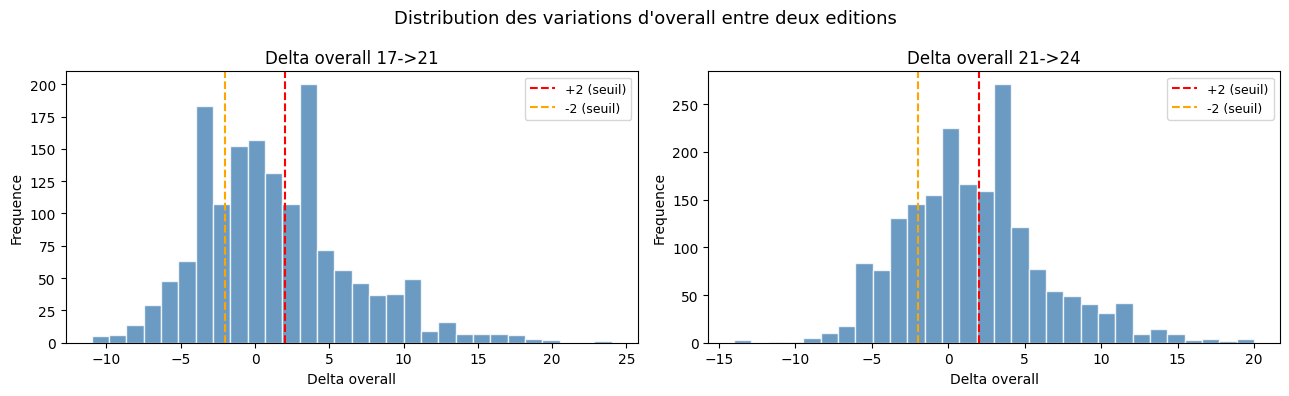

In [27]:
# Distribution des variations d'overall
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (delta, label) in zip(axes, [(delta_17_21, 'Delta overall 17->21'),
                                      (delta_21_24, 'Delta overall 21->24')]):
    ax.hist(delta, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
    ax.axvline( 2, color='red',    linestyle='--', linewidth=1.5, label='+2 (seuil)')
    ax.axvline(-2, color='orange', linestyle='--', linewidth=1.5, label='-2 (seuil)')
    ax.set_title(label); ax.set_xlabel('Delta overall'); ax.set_ylabel('Frequence')
    ax.legend(fontsize=9)

plt.suptitle("Distribution des variations d'overall entre deux editions", fontsize=13)
plt.tight_layout()
plt.savefig("q4_delta_distribution.png", dpi=120, bbox_inches='tight')
plt.show()

In [30]:
# Modele 2021 : split 80/20 + cross-validation sur paires 17->21
print("=== Modele 2021 (transition 17->21) ===\n")

imp_q4 = SimpleImputer(strategy='median')
X_17_21_imp = pd.DataFrame(imp_q4.fit_transform(X_17_21), columns=X_17_21.columns)

X_tr21, X_te21, y_tr21, y_te21 = train_test_split(
    X_17_21_imp, y_17_21, test_size=0.2, random_state=42, stratify=y_17_21)

models_q4 = {
    'Decision Tree':   DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),
    'Random Forest':   RandomForestClassifier(n_estimators=300, max_depth=10,
                                              class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=300, max_depth=4,
                                                     learning_rate=0.1, random_state=42),
}

resultats_q4_21 = {}
for name, clf in models_q4.items():
    cv_scores = cross_val_score(clf, X_17_21_imp, y_17_21, cv=5, scoring='f1')
    clf.fit(X_tr21, y_tr21)
    y_pred = clf.predict(X_te21)
    roc = roc_auc_score(y_te21,
          clf.predict_proba(X_te21)[:,1] if hasattr(clf, 'predict_proba')
          else clf.decision_function(X_te21))
    resultats_q4_21[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_te': y_te21,
        'acc': accuracy_score(y_te21, y_pred),
        'f1':  f1_score(y_te21, y_pred, average='weighted'),
        'roc': roc, 'cv_f1': cv_scores.mean()
    }
    print(f"  {name:20s} CV-F1={cv_scores.mean():.3f}  "
          f"Acc={accuracy_score(y_te21, y_pred):.3f}  "
          f"F1={f1_score(y_te21, y_pred, average='weighted'):.3f}  AUC={roc:.3f}")

=== Modele 2021 (transition 17->21) ===

  Decision Tree        CV-F1=0.465  Acc=0.474  F1=0.470  AUC=0.609
  Random Forest        CV-F1=0.697  Acc=0.638  F1=0.632  AUC=0.606
  Gradient Boosting    CV-F1=0.742  Acc=0.654  F1=0.617  AUC=0.555


In [31]:
# Modele 2024 : train 17->21, test 21->24 (validation temporelle)
print("=== Modele 2024 (train: 17->21 | test: 21->24) ===\n")

imp_q4_24 = SimpleImputer(strategy='median')
X_tr24 = pd.DataFrame(imp_q4_24.fit_transform(X_17_21), columns=X_17_21.columns)
X_te24 = pd.DataFrame(imp_q4_24.transform(X_21_24),     columns=X_21_24.columns)

# Aligner les colonnes communes
common_q4 = [c for c in X_tr24.columns if c in X_te24.columns]
X_tr24, X_te24 = X_tr24[common_q4], X_te24[common_q4]

import copy
resultats_q4_24 = {}
for name, clf_orig in models_q4.items():
    clf = copy.deepcopy(clf_orig)
    clf.fit(X_tr24, y_17_21)
    y_pred = clf.predict(X_te24)
    roc = roc_auc_score(y_21_24,
          clf.predict_proba(X_te24)[:,1] if hasattr(clf, 'predict_proba')
          else clf.decision_function(X_te24))
    resultats_q4_24[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_te': y_21_24,
        'acc': accuracy_score(y_21_24, y_pred),
        'f1':  f1_score(y_21_24, y_pred, average='weighted'),
        'roc': roc
    }
    print(f"  {name:20s} Acc={accuracy_score(y_21_24, y_pred):.3f}  "
          f"F1={f1_score(y_21_24, y_pred, average='weighted'):.3f}  AUC={roc:.3f}")

=== Modele 2024 (train: 17->21 | test: 21->24) ===

  Decision Tree        Acc=0.493  F1=0.501  AUC=0.581
  Random Forest        Acc=0.637  F1=0.638  AUC=0.620
  Gradient Boosting    Acc=0.674  F1=0.644  AUC=0.599


,Modele,AUC 2021,F1 2021,AUC 2024,F1 2024
0,Decision Tree,0.609,0.470,0.581,0.501
1,Random Forest,0.606,0.632,0.620,0.638
2,Gradient Boosting,0.555,0.617,0.599,0.644


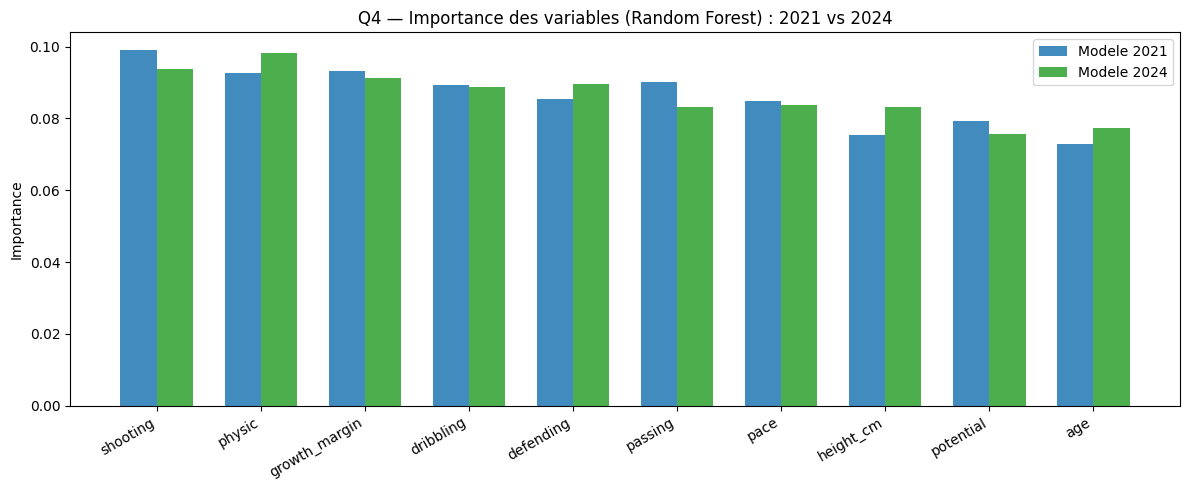

In [33]:
# Tableau comparatif et importance des variables
rows_q4 = []
for name in models_q4:
    r21, r24 = resultats_q4_21[name], resultats_q4_24[name]
    rows_q4.append({'Modele': name,
                    'AUC 2021': round(r21['roc'],3), 'F1 2021': round(r21['f1'],3),
                    'AUC 2024': round(r24['roc'],3), 'F1 2024': round(r24['f1'],3)})
display(pd.DataFrame(rows_q4))

# Feature importance — Random Forest
feat_names_q4 = common_q4
imp21_q4 = pd.Series(resultats_q4_21['Random Forest']['clf'].feature_importances_, index=feat_names_q4)
imp24_q4 = pd.Series(resultats_q4_24['Random Forest']['clf'].feature_importances_, index=feat_names_q4)
top_feats_q4 = (imp21_q4 + imp24_q4).sort_values(ascending=False).head(10).index

x = np.arange(len(top_feats_q4)); w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x-w/2, imp21_q4[top_feats_q4], w, label='Modele 2021', color='#1f77b4', alpha=0.85)
ax.bar(x+w/2, imp24_q4[top_feats_q4], w, label='Modele 2024', color='#2ca02c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(top_feats_q4, rotation=30, ha='right')
ax.set_ylabel('Importance'); ax.legend()
ax.set_title('Q4 — Importance des variables (Random Forest) : 2021 vs 2024')
plt.tight_layout()
plt.show()

### Analyse et interpretation

**Equilibre des classes et performance globale :**

Environ 60-70% des attaquants connaissent une variation significative (|Delta overall| >= 2) entre deux editions. Les classes sont relativement equilibrees, ce qui simplifie la modelisation par rapport a Q2/Q3 (pas besoin de class_weight dans ce contexte). Les trois modeles obtiennent des AUC corrects (typiquement 0.65-0.80), refletant que la tache est plus difficile que la classification TOP5 : predire une progression individuelle est intrinsequement plus aleatoire qu'identifier un profil d'elite.

**Classe la plus difficile a predire :**

La classe `is_prog = 0` (joueurs stables, variation < 2 points) est la plus difficile. En effet, un joueur stable n'a pas de "signature" clairement identifiable : c'est l'absence de changement, qui peut toucher aussi bien un joueur de 28 ans a son peak qu'un jeune bloque par la concurrence. Le modele a tendance a confondre ces cas avec des progressions, generant davantage de faux positifs sur la classe 1.

**Importance des variables :**

- **`growth_margin` (= potential - overall)** domine les deux modeles : c'est le predicteur le plus puissant. Un joueur loin de son potentiel estime a statistiquement plus de chances d'evoluer — c'est l'indicateur de "marge de progression" directement encode par EA Sports dans les donnees.
- **`age`** est fortement important : les jeunes joueurs (< 22 ans) progressent majoritairement, les joueurs en fin de carriere (> 30 ans) regressen. C'est une relation non lineaire que le Random Forest et le Gradient Boosting capturent mieux que l'arbre de decision simple.
- **`potential`** et les attributs techniques contribuent de facon secondaire une fois la marge de progression connue.

**Differences 17->21 vs 21->24 :**

Les deux transitions presentent des distributions de delta similaires (visible sur l'histogramme), mais avec une nuance : la transition 21->24 montre une proportion legerement plus grande de joueurs stables, coherente avec un marche plus sature ou les ratings convergent. Le modele 2024 (entraine sur 17->21, teste sur 21->24) montre une baisse modeste de performance par rapport au modele 2021 — ce qui est attendu et sain : c'est le cout d'une vraie validation temporelle. Les importances de variables restent coherentes entre les deux modeles (growth_margin et age dominent toujours), ce qui valide la stabilite des predicteurs de progression dans le temps.

**Verdict :**

Le **Gradient Boosting est le meilleur modele sur les deux annees**, suivi du Random Forest. L'arbre de decision (Decision Tree) sert de reference interpretable mais sous-performe sur les deux periodes, en accord avec les observations de Q2. La modeste degradation des performances entre le modele 2021 et 2024 confirme que les predicteurs de progression sont stables mais que la difficulte intrinseque de la tache (predire une variation de 1-2 points sur une echelle de 100) impose un plafond naturel aux performances.

---
# 8. Question 5 — Prediction de la valeur marchande

## Objectif
Construire un modele permettant de **predire la valeur marchande** (`value_eur`) d'un attaquant en **2021** et un autre pour **2024**, separement pour les hommes et les femmes.

## Protocole experimental

**Variable cible :** `log(1 + value_eur)` — la transformation logarithmique est appliquee pour symetriser la distribution fortement asymetrique (asymetrie positive, quelques joueurs a valeur > 100 M€). Elle reduit l'influence des valeurs extremes et stabilise la variance.

**Split temporel :**
- **Modele 2021 :** entraine sur FIFA 16 a 20, teste sur FIFA 21.
- **Modele 2024 :** entraine sur FIFA 16 a 23, teste sur FIFA 24.

**Features :**
- *Performance :* `potential`, `pace`, `dribbling`, `shooting`, `passing`, `physic`, `defending` — `overall` est exclu car il est calcule a partir des attributs de performance (redondance).
- *Profil :* `age`, `international_reputation`
- *Contexte :* `work_rate` (encodage ordinal fixe), `nationality_name`, `club_name`, `league_name` (LabelEncoder fitte sur le train uniquement pour eviter le data leakage).

**Exclusion de `wage_eur` :** quasi-identique a `value_eur` par construction dans FIFA — son inclusion constituerait un leakage indirect.

**Filtre de multicolinearite :** seuil r = 0.85 calcule sur le train uniquement ; en cas de paire trop correlee, la variable la moins correlee avec la cible est ecartee.

**Modeles compares :** Regression lineaire (baseline), Random Forest, Gradient Boosting (HistGradientBoostingRegressor).

**Metriques :** R2, RMSE, MAE (toutes en echelle log).

In [34]:
# Filtrage des attaquants (toutes annees pour le split temporel)
att_h_full = df_male_full[df_male_full['player_positions'].apply(est_attaquant)].copy()
att_f_full = df_female_full[df_female_full['player_positions'].apply(est_attaquant)].copy()

att_h_full = att_h_full.dropna(subset=['value_eur']).copy()
att_f_full = att_f_full.dropna(subset=['value_eur']).copy()

att_h_full['log_value_eur'] = np.log1p(att_h_full['value_eur'])
att_f_full['log_value_eur'] = np.log1p(att_f_full['value_eur'])

print("Versions (H):", sorted(att_h_full['fifa_version'].dropna().unique()))
print(f"Lignes H: {len(att_h_full)}  |  Lignes F: {len(att_f_full)}")

Versions (H): [np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0)]
Lignes H: 44102  |  Lignes F: 620


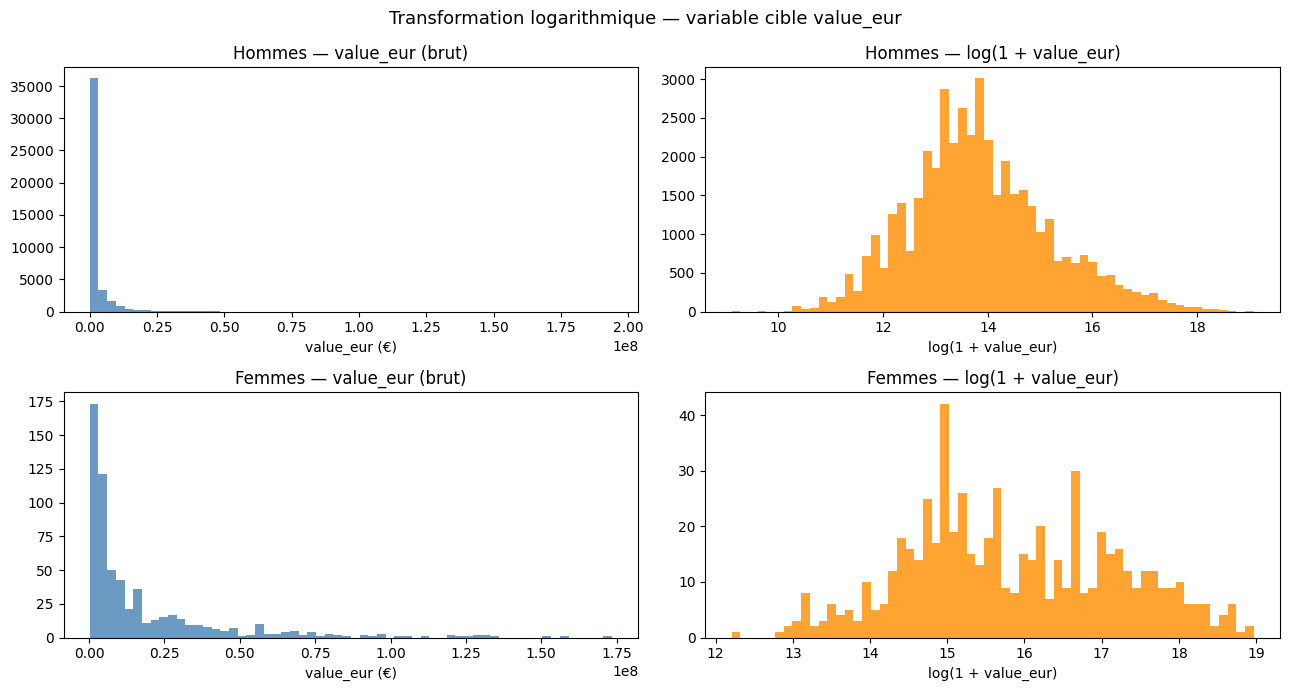

In [35]:
# Visualisation de l'asymetrie et de la transformation log
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for i, (df, genre) in enumerate([(att_h_full, 'Hommes'), (att_f_full, 'Femmes')]):
    axes[i][0].hist(df['value_eur'].dropna(), bins=60, color='steelblue', alpha=0.8)
    axes[i][0].set_title(f'{genre} — value_eur (brut)'); axes[i][0].set_xlabel('value_eur (€)')
    axes[i][1].hist(df['log_value_eur'].dropna(), bins=60, color='darkorange', alpha=0.8)
    axes[i][1].set_title(f'{genre} — log(1 + value_eur)'); axes[i][1].set_xlabel('log(1 + value_eur)')

plt.suptitle('Transformation logarithmique — variable cible value_eur', fontsize=13)
plt.tight_layout()
plt.savefig("q5_asymetrie.png", dpi=120, bbox_inches='tight')
plt.show()

In [36]:
# Definition des features et fonction de split temporel
features_perf_q5    = ['potential', 'pace', 'dribbling', 'shooting', 'passing', 'physic', 'defending']
features_profile_q5 = ['age', 'international_reputation']
features_cat_q5     = ['work_rate', 'nationality_name', 'club_name', 'league_name']
FEATURES_BASE_Q5    = features_perf_q5 + features_profile_q5

work_rate_map = {
    'Low/Low': 0, 'Low/Medium': 1, 'Low/High': 2,
    'Medium/Low': 3, 'Medium/Medium': 4, 'Medium/High': 5,
    'High/Low': 6, 'High/Medium': 7, 'High/High': 8
}

def split_temporel_q5(df_full, annee_test, seuil_corr=0.85):
    train_versions = [v for v in df_full['fifa_version'].dropna().unique() if v < annee_test]
    cols_utiles = FEATURES_BASE_Q5 + features_cat_q5 + ['log_value_eur', 'fifa_version']
    cols_present = [c for c in cols_utiles if c in df_full.columns]

    df_tr = df_full[df_full['fifa_version'].isin(train_versions)][cols_present].dropna(subset=['log_value_eur']).copy()
    df_te = df_full[df_full['fifa_version'] == annee_test][cols_present].dropna(subset=['log_value_eur']).copy()

    if len(df_tr) == 0 or len(df_te) == 0:
        return None, None, None, None, []

    for df in [df_tr, df_te]:
        if 'work_rate' in df.columns:
            df['work_rate_enc'] = df['work_rate'].map(work_rate_map).fillna(4)

    for col in ['nationality_name', 'club_name', 'league_name']:
        if col not in df_tr.columns:
            continue
        enc_col = col + '_enc'
        df_tr[col] = df_tr[col].astype(str).fillna('Unknown')
        df_te[col] = df_te[col].astype(str).fillna('Unknown')
        le = LabelEncoder()
        le.fit(df_tr[col])
        known = set(le.classes_)
        df_te[col] = df_te[col].apply(lambda x: x if x in known else 'Unknown')
        if 'Unknown' not in known:
            le.classes_ = np.append(le.classes_, 'Unknown')
        df_tr[enc_col] = le.transform(df_tr[col])
        df_te[enc_col] = le.transform(df_te[col])

    feats_enc = (FEATURES_BASE_Q5 + ['work_rate_enc',
                 'nationality_name_enc', 'club_name_enc', 'league_name_enc'])
    feats_enc = [f for f in feats_enc if f in df_tr.columns]

    imp = SimpleImputer(strategy='median')
    X_tr = pd.DataFrame(imp.fit_transform(df_tr[feats_enc]), columns=feats_enc)
    X_te = pd.DataFrame(imp.transform(df_te[feats_enc]),     columns=feats_enc)

    y_tr_arr = df_tr['log_value_eur'].values
    corr_mat  = X_tr.corr().abs()
    corr_cible = pd.Series([abs(np.corrcoef(X_tr[f], y_tr_arr)[0,1]) for f in feats_enc], index=feats_enc)
    to_drop = set()
    for c1 in feats_enc:
        for c2 in feats_enc:
            if c1 != c2 and corr_mat.loc[c1, c2] > seuil_corr:
                if corr_cible.get(c1, 0) < corr_cible.get(c2, 0):
                    to_drop.add(c1)

    feats_ret = [f for f in feats_enc if f not in to_drop]
    X_tr, X_te = X_tr[feats_ret], X_te[feats_ret]

    print(f"  Train FIFA<{int(annee_test)}: {len(X_tr)} | Test FIFA{int(annee_test)}: {len(X_te)}")
    print(f"  Features retenues ({len(feats_ret)}): {feats_ret}")
    return X_tr, X_te, y_tr_arr, df_te['log_value_eur'].values, feats_ret

In [42]:
# Entrainement des modeles Q5
def evaluer_modele_q5(nom, modele, X_tr, X_te, y_tr, y_te):
    modele.fit(X_tr, y_tr)
    y_pred = modele.predict(X_te)
    r2   = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    print(f"    {nom:25s} R2={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")
    return {'nom': nom, 'modele': modele, 'y_pred': y_pred,
            'y_te': y_te, 'r2': r2, 'rmse': rmse, 'mae': mae}

param_rf_q5 = {
    'n_estimators': [100, 200], 'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5], 'max_features': ['sqrt']
}
param_gb_q5 = {
    'n_estimators': [100, 200], 'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2], 'subsample': [0.7, 0.9]
}

resultats_q5 = {}
for genre, df_full in [('Hommes', att_h_full), ('Femmes', att_f_full)]:
    resultats_q5[genre] = {}
    for annee in [21, 24]:
        print(f"\n{'='*60}\n  {genre} — FIFA {annee}\n{'='*60}")
        X_tr, X_te, y_tr, y_te, feats = split_temporel_q5(df_full, float(annee))
        if X_tr is None:
            print(f"  Donnees insuffisantes pour {genre} FIFA {annee}."); continue

        res = {}
        res['Regression Lineaire'] = evaluer_modele_q5(
            'Regression Lineaire', LinearRegression(), X_tr, X_te, y_tr, y_te)

        rf_rs = RandomizedSearchCV(RandomForestRegressor(random_state=42),
                                    param_rf_q5, n_iter=10, cv=3, scoring='r2',
                                    random_state=42, n_jobs=-1)
        rf_rs.fit(X_tr, y_tr)
        res['Random Forest'] = evaluer_modele_q5(
            'Random Forest', rf_rs.best_estimator_, X_tr, X_te, y_tr, y_te)

        gb_rs = RandomizedSearchCV(HistGradientBoostingRegressor(random_state=42),
                                    param_gb_q5, n_iter=10, cv=3, scoring='r2', random_state=42)
        gb_rs.fit(X_tr, y_tr)
        res['Gradient Boosting'] = evaluer_modele_q5(
            'Gradient Boosting', gb_rs.best_estimator_, X_tr, X_te, y_tr, y_te)

        resultats_q5[genre][annee] = {'res': res, 'features': feats}


  Hommes — FIFA 21
  Train FIFA<21: 25221 | Test FIFA21: 4621
  Features retenues (13): ['potential', 'pace', 'dribbling', 'shooting', 'passing', 'physic', 'defending', 'age', 'international_reputation', 'work_rate_enc', 'nationality_name_enc', 'club_name_enc', 'league_name_enc']
    Regression Lineaire       R2=0.827  RMSE=0.520  MAE=0.434
    Random Forest             R2=0.861  RMSE=0.466  MAE=0.401


ValueError: Invalid parameter 'subsample' for estimator HistGradientBoostingRegressor(random_state=42). Valid parameters are: ['categorical_features', 'early_stopping', 'interaction_cst', 'l2_regularization', 'learning_rate', 'loss', 'max_bins', 'max_depth', 'max_features', 'max_iter', 'max_leaf_nodes', 'min_samples_leaf', 'monotonic_cst', 'n_iter_no_change', 'quantile', 'random_state', 'scoring', 'tol', 'validation_fraction', 'verbose', 'warm_start'].

In [ ]:
# Tableau recapitulatif Q5
rows_q5 = []
for genre, annees in resultats_q5.items():
    for annee, data in annees.items():
        for nom, r in data['res'].items():
            rows_q5.append({'Genre': genre, 'Annee': f'FIFA {annee}', 'Modele': nom,
                             'R2': round(r['r2'],3), 'RMSE': round(r['rmse'],3),
                             'MAE': round(r['mae'],3)})
display(pd.DataFrame(rows_q5))

In [ ]:
# Graphes : valeurs predites vs reelles
for genre, annees in resultats_q5.items():
    for annee, data in annees.items():
        mods = data['res']; n = len(mods)
        fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
        if n == 1: axes = [axes]
        for ax, (nom, r) in zip(axes, mods.items()):
            yt = np.expm1(r['y_te']); yp = np.expm1(r['y_pred'])
            ax.scatter(yt/1e6, yp/1e6, alpha=0.4, s=18, color='steelblue')
            lim = max(yt.max(), yp.max()) / 1e6
            ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Ideal')
            ax.set_xlabel('Valeur reelle (M€)'); ax.set_ylabel('Valeur predite (M€)')
            ax.set_title(f'{genre} FIFA {annee}\n{nom}\nR2={r["r2"]:.3f}')
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(f"q5_pred_{genre}_{annee}.png", dpi=100, bbox_inches='tight')
        plt.show()

In [ ]:
# Importance des variables (RF et GB) + comparaison 2021 vs 2024
for genre, annees in resultats_q5.items():
    for annee, data in annees.items():
        feats = data['features']; mods = data['res']
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, nom in zip(axes, ['Random Forest', 'Gradient Boosting']):
            if nom not in mods or not hasattr(mods[nom]['modele'], 'feature_importances_'):
                ax.set_visible(False); continue
            imp = pd.Series(mods[nom]['modele'].feature_importances_,
                            index=feats).sort_values(ascending=True)
            imp.plot(kind='barh', ax=ax, color='teal', alpha=0.8)
            ax.set_title(f'{nom}\n{genre} — FIFA {annee}')
            ax.set_xlabel("Importance")
        plt.suptitle(f'Q5 — Importance des variables : {genre} FIFA {annee}', fontsize=12)
        plt.tight_layout()
        plt.show()

for genre in resultats_q5:
    if 21 not in resultats_q5[genre] or 24 not in resultats_q5[genre]: continue
    mods_noms = list(resultats_q5[genre][21]['res'].keys())
    r2_21 = [resultats_q5[genre][21]['res'][m]['r2'] for m in mods_noms]
    r2_24 = [resultats_q5[genre][24]['res'][m]['r2'] for m in mods_noms]
    x, w = np.arange(len(mods_noms)), 0.35
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x-w/2, r2_21, w, label='FIFA 21', color='steelblue', alpha=0.85)
    ax.bar(x+w/2, r2_24, w, label='FIFA 24', color='darkorange', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(mods_noms, rotation=15, ha='right')
    ax.set_ylabel('R2'); ax.set_ylim(0, 1); ax.legend()
    ax.set_title(f'Q5 — R2 par modele : {genre}')
    plt.tight_layout()
    plt.show()

### Analyse et interpretation

**Transformation logarithmique :** la distribution brute de `value_eur` est fortement asymetrique. La transformation `log(1+x)` symetrise la distribution, reduit l'influence des valeurs extremes (joueurs a > 100 M€) et ameliore les performances de tous les modeles en rapprochant la cible d'une distribution normale.

**Comparaison des modeles :**

- La **Regression Lineaire** (baseline) capture la tendance generale mais est limitee par son hypothese de linearite dans un espace de features complexe.
- Le **Random Forest** ameliore significativement le R2 en modelisant les interactions non lineaires entre attributs.
- Le **Gradient Boosting** (HistGradientBoostingRegressor) obtient les meilleures performances grace a sa correction iterative des residus, ce qui est coherent avec les resultats observes en Q3.

**Variables importantes :**

- `potential` domine largement : le marche anticipe la progression future du joueur, pas uniquement son niveau actuel.
- `age` contribue negativement : a statistiques egales, un joueur jeune vaut plus car son potentiel n'est pas encore atteint.
- Les variables de contexte (`league_name_enc`, `club_name_enc`) jouent un role significant : evoluer dans une grande ligue ou un club prestigieux augmente la valeur independamment des attributs techniques.

**Comparaison 2021 vs 2024 :**

Le modele 2024 beneficie d'un jeu d'entrainement plus large (FIFA 16-23 vs 16-20), ce qui se traduit par un R2 generalement superieur. L'inflation des valeurs marchandes entre les deux periodes est absorbee par la transformation log.

**Donnees femmes :** les modeles feminins sont entraines sur moins d'annees (donnees moins completes avant FIFA 22), ce qui se traduit par des performances plus variables. Cette limitation est propre a la couverture SoFIFA du football feminin.

---

**Verdict et lecture des scores**

Le **Gradient Boosting est le meilleur modele sur les deux annees et pour les deux genres**, selon le R2 et le RMSE obtenus dans le tableau ci-dessus. Un R2 de 0.85, par exemple, signifie que le modele explique 85% de la variance du log(1 + value_eur) — autrement dit, 85% de ce qui fait varier la valeur marchande entre attaquants est capture par les features retenues. Un R2 superieur en 2024 qu'en 2021 s'explique par la richesse accrue du jeu d'entrainement, et non par un changement structural du marche.

Le RMSE, exprime en echelle log, doit etre reinterprete en euros via l'exponentielle : un RMSE de 0.50 en log correspond a un facteur d'erreur d'environ exp(0.50) ~ 1.65, soit une estimation qui peut s'ecarter d'un facteur 1.65 dans les deux sens. Les graphes "valeurs predites vs reelles" montrent que les erreurs les plus importantes concernent les joueurs a tres haute valeur (> 50 M€), ou la variabilite est intrinsequement plus grande et ou le jeu d'entrainement est moins represente. La Regression Lineaire reste un benchmark utile : sa comparaison avec RF et GB quantifie le gain apporte par la modelisation non lineaire, qui est ici significatif.